# BioSentinel India — Person 3: AI & Anomaly Intelligence

**Owner:** Person 3

This notebook contains the Person 3 technical pipeline:

1. Effort-aware anomaly feature construction
2. Statistical anomaly detection
3. Isolation Forest anomaly detection
4. Anomaly sensitivity and stability diagnostics
5. Explainable priority scoring
6. Spatial visualization of flagged Grid × Year units
7. EfficientNet-B0 transfer learning for biodiversity image species identification
8. Model evaluation and checkpoint export

### Interpretation rule

The anomaly pipeline identifies **potentially unusual observation-derived biodiversity patterns**. An anomaly is **not** interpreted as direct evidence of biodiversity loss, recovery, population decline, or ecological damage.

Sampling effort, historical baseline support, and data quality are carried forward from Persons 1 and 2.

The image-classification pipeline is a separate component: it predicts species from images and reports standard machine-learning evaluation metrics.


## Pipeline overview

```text
Person 1 biodiversity indicators
        +
Person 2 spatial-temporal analysis
        ↓
Effort-aware feature engineering
        ↓
Statistical anomaly evidence
        +
Isolation Forest
        ↓
Combined anomaly evidence
        ↓
Persistence + coverage
        ↓
Explainable priority score
```

The image branch is independent of the Grid × Year anomaly branch:

```text
Biodiversity images
        ↓
Dataset audit
        ↓
Image preprocessing / augmentation
        ↓
EfficientNet-B0 transfer learning
        ↓
Validation + test evaluation
        ↓
Species + confidence
```


## 1. Setup, paths, and configuration

In [2]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    top_k_accuracy_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)

# -----------------------------
# Project paths
# -----------------------------
def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (
            (candidate / "data").exists()
            and (candidate / "notebooks").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not find the BioSentinel project root containing data/ and notebooks/."
    )

PROJECT_ROOT = find_project_root()

ANALYTICS_DIR = PROJECT_ROOT / "data" / "processed" / "analytics"
SPATIOTEMPORAL_PATH = ANALYTICS_DIR / "grid_year_spatial_temporal_intelligence.parquet"
GBIF_TERRESTRIAL_PATH = PROJECT_ROOT / "data" / "processed" / "gbif_terrestrial_species_year_grid.parquet"

IMAGE_ROOT = PROJECT_ROOT / "data" / "raw" / "inaturalist" / "images"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = ANALYTICS_DIR / "person3"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Analysis configuration
# -----------------------------
ANALYSIS_START_YEAR = 2018
ANALYSIS_END_YEAR = 2024
MODEL_TRAIN_END_YEAR = 2023

MIN_OCCURRENCES_FOR_COMPARISON = 25
MIN_BASELINE_YEARS = 3
ROBUST_DEVIATION_THRESHOLD = 3.0
ANOMALY_PERCENTILE_THRESHOLD = 95.0
IF_CONTAMINATION = 0.05
IF_RANDOM_STATE = 42

W_ANOMALY = 0.55
W_COMPOSITION = 0.15
W_PERSISTENCE = 0.15
W_COVERAGE = 0.15

# -----------------------------
# Experiment 2 image paths
# -----------------------------
IMAGE_MASTER_MANIFEST_PATH = (
    PROJECT_ROOT / "data" / "processed" / "inaturalist" / "efficientnet_manifest.csv"
)

IMAGE_BASELINE_MANIFEST_PATH = (
    PROJECT_ROOT / "data" / "processed" / "inaturalist" / "efficientnet_30_reuse_manifest.csv"
)

IMAGE_MANIFEST_PATH = (
    PROJECT_ROOT / "data" / "processed" / "inaturalist" / "efficientnet_50_exp2_manifest.csv"
)

IMAGE_EXP2_OUTPUT_DIR = OUTPUT_DIR / "efficientnet_exp2_50img"
IMAGE_EXP2_MODEL_DIR = MODEL_DIR / "efficientnet_exp2_50img"
IMAGE_EXP2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_EXP2_MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Spatio-temporal input:", SPATIOTEMPORAL_PATH)
print("GBIF terrestrial input:", GBIF_TERRESTRIAL_PATH)
print("Image root:", IMAGE_ROOT)
print("Experiment 2 master manifest:", IMAGE_MASTER_MANIFEST_PATH)
print("Experiment 1 baseline manifest:", IMAGE_BASELINE_MANIFEST_PATH)
print("Experiment 2 manifest:", IMAGE_MANIFEST_PATH)
print("Experiment 2 output:", IMAGE_EXP2_OUTPUT_DIR)
print("Experiment 2 model dir:", IMAGE_EXP2_MODEL_DIR)
print(f"Analysis period: {ANALYSIS_START_YEAR}-{ANALYSIS_END_YEAR}")
print(f"Isolation Forest training period: {ANALYSIS_START_YEAR}-{MODEL_TRAIN_END_YEAR}")


Project root: d:\Biosential_India
Spatio-temporal input: d:\Biosential_India\data\processed\analytics\grid_year_spatial_temporal_intelligence.parquet
GBIF terrestrial input: d:\Biosential_India\data\processed\gbif_terrestrial_species_year_grid.parquet
Image root: d:\Biosential_India\data\raw\inaturalist\images
Experiment 2 master manifest: d:\Biosential_India\data\processed\inaturalist\efficientnet_manifest.csv
Experiment 1 baseline manifest: d:\Biosential_India\data\processed\inaturalist\efficientnet_30_reuse_manifest.csv
Experiment 2 manifest: d:\Biosential_India\data\processed\inaturalist\efficientnet_50_exp2_manifest.csv
Experiment 2 output: d:\Biosential_India\data\processed\analytics\person3\efficientnet_exp2_50img
Experiment 2 model dir: d:\Biosential_India\models\efficientnet_exp2_50img
Analysis period: 2018-2024
Isolation Forest training period: 2018-2023


## 2. Load Person 2's finalized spatial-temporal dataset

In [3]:
REQUIRED_COLUMNS = [
    "eqdcellcode",
    "year",
    "total_occurrences",
    "species_richness",
    "shannon_diversity",
    "simpson_diversity",
    "pielou_evenness",
    "sampling_adequate",
    "sampling_flag",
    "baseline_years",
    "baseline_start_year",
    "baseline_end_year",
    "baseline_richness_median",
    "baseline_richness_mean",
    "baseline_richness_q1",
    "baseline_richness_q3",
    "baseline_iqr",
    "baseline_supported",
    "richness_deviation_from_baseline",
    "baseline_relative_change_pct",
    "baseline_flag",
]

if not SPATIOTEMPORAL_PATH.exists():
    raise FileNotFoundError(
        f"Person 2 output not found: {SPATIOTEMPORAL_PATH}"
    )

pf = pq.ParquetFile(SPATIOTEMPORAL_PATH)

missing = sorted(
    set(REQUIRED_COLUMNS) - set(pf.schema.names)
)

if missing:
    raise ValueError(
        f"Person 2 dataset is missing required columns: {missing}"
    )

data = pd.read_parquet(
    SPATIOTEMPORAL_PATH,
    columns=REQUIRED_COLUMNS,
)

data["year"] = pd.to_numeric(data["year"], errors="raise").astype(int)
data["total_occurrences"] = pd.to_numeric(
    data["total_occurrences"], errors="raise"
)
data["species_richness"] = pd.to_numeric(
    data["species_richness"], errors="raise"
)

data = data[
    data["year"].between(
        ANALYSIS_START_YEAR,
        ANALYSIS_END_YEAR,
    )
].copy()

print("Rows:", f"{len(data):,}")
print("Grid cells:", f"{data['eqdcellcode'].nunique():,}")
print("Years:", sorted(data["year"].unique()))
print(
    "Underlying observation records:",
    f"{data['total_occurrences'].sum():,}"
)

print("\nSampling flags:")
print(data["sampling_flag"].value_counts(dropna=False))

print("\nBaseline flags:")
print(data["baseline_flag"].value_counts(dropna=False))


Rows: 27,830
Grid cells: 6,457
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Underlying observation records: 51,604,362

Sampling flags:
sampling_flag
usable_with_caution    18772
data_limited            9058
Name: count, dtype: int64

Baseline flags:
baseline_flag
baseline_supported                 12913
data_limited_current_year           9058
insufficient_historical_support     5859
Name: count, dtype: int64


## 3. Define eligible anomaly-analysis units

In [4]:
eligible = data[
    data["sampling_adequate"].fillna(False).astype(bool)
    & data["baseline_supported"].fillna(False).astype(bool)
].copy()

if eligible.empty:
    raise ValueError(
        "No eligible Grid × Year units are available for anomaly analysis."
    )

eligible = eligible.sort_values(
    ["eqdcellcode", "year"]
).reset_index(drop=True)

print(
    "Eligible Grid × Year units:",
    f"{len(eligible):,}"
)
print(
    "Eligible grid cells:",
    f"{eligible['eqdcellcode'].nunique():,}"
)
print(
    "Eligible years:",
    sorted(eligible["year"].unique())
)


Eligible Grid × Year units: 12,913
Eligible grid cells: 2,773
Eligible years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 4. Effort-aware anomaly features

### Features

- `richness_iqr_scaled_deviation`: deviation from the grid-specific historical median, scaled by the historical IQR.
- `effort_adjusted_richness_residual`: residual after modelling observed richness against log observation effort.
- `composition_proxy`: magnitude of changes in Shannon diversity, Simpson diversity, and Pielou evenness.
- `consecutive_year`: whether a previous row represents the immediately preceding year.

These are deliberately observation-aware features. The `occurrences` field represents GBIF records, so it is treated as observation effort rather than animal abundance.


In [5]:
# Historical-baseline deviation
eligible["baseline_iqr_safe"] = eligible["baseline_iqr"].fillna(0).clip(lower=1)

eligible["richness_iqr_scaled_deviation"] = (
    eligible["richness_deviation_from_baseline"]
    / eligible["baseline_iqr_safe"]
)

eligible["abs_richness_iqr_scaled_deviation"] = (
    eligible["richness_iqr_scaled_deviation"].abs()
)

# Log observation effort
eligible["log_observation_effort"] = np.log1p(
    eligible["total_occurrences"].clip(lower=0)
)

# Consecutive-year changes within a grid cell
grouped = eligible.groupby("eqdcellcode", sort=False)

eligible["previous_year"] = grouped["year"].shift(1)
eligible["year_gap"] = (
    eligible["year"] - eligible["previous_year"]
)

eligible["consecutive_year"] = eligible["year_gap"].eq(1)

for col in [
    "species_richness",
    "shannon_diversity",
    "simpson_diversity",
    "pielou_evenness",
]:
    eligible[f"previous_{col}"] = grouped[col].shift(1)
    eligible[f"delta_{col}"] = np.where(
        eligible["consecutive_year"],
        eligible[col] - eligible[f"previous_{col}"],
        np.nan,
    )
    eligible[f"abs_delta_{col}"] = eligible[f"delta_{col}"].abs()

eligible["composition_proxy_raw"] = (
    eligible["abs_delta_shannon_diversity"].fillna(0)
    + eligible["abs_delta_simpson_diversity"].fillna(0)
    + eligible["abs_delta_pielou_evenness"].fillna(0)
) / 3.0

print("Feature columns created.")
eligible[
    [
        "eqdcellcode",
        "year",
        "species_richness",
        "total_occurrences",
        "richness_iqr_scaled_deviation",
        "composition_proxy_raw",
    ]
].head(10)


Feature columns created.


,eqdcellcode,year,species_richness,total_occurrences,richness_iqr_scaled_deviation,composition_proxy_raw
0,E068N22DB,2021,163,1565,3.272727,0.000000
1,E068N22DB,2022,114,508,-0.909091,0.068877
2,E068N22DB,2023,176,1789,2.882353,0.083183
3,E068N22DB,2024,156,1744,0.715232,0.037417
4,E068N22DD,2021,85,200,2.074074,0.000000
5,E068N22DD,2022,32,53,-1.555556,0.342336
6,E068N22DD,2023,111,598,2.000000,0.373419
7,E068N22DD,2024,98,360,0.992806,0.046181
8,E068N23BA,2024,42,135,-0.127660,0.000000
9,E068N23BB,2023,63,226,0.607595,0.000000


## 5. Model observation effort and calculate effort-adjusted richness

A simple regression is fit only on the historical training period (`2018–2023`). Its purpose is not ecological prediction; it estimates how observed species richness changes with observation volume in this dataset.

The residual is then used as one piece of anomaly evidence.


In [6]:
train_effort = eligible[
    eligible["year"].between(
        ANALYSIS_START_YEAR,
        MODEL_TRAIN_END_YEAR,
    )
].copy()

if len(train_effort) < 20:
    raise ValueError(
        f"Too few historical training rows for effort model: {len(train_effort)}"
    )

X_effort = train_effort[
    ["log_observation_effort"]
].to_numpy()

y_effort = train_effort[
    "species_richness"
].to_numpy()

effort_model = LinearRegression()
effort_model.fit(X_effort, y_effort)

eligible["predicted_richness_from_effort"] = effort_model.predict(
    eligible[["log_observation_effort"]].to_numpy()
)

eligible["effort_adjusted_richness_residual"] = (
    eligible["species_richness"]
    - eligible["predicted_richness_from_effort"]
)

print(
    "Effort model coefficient:",
    float(effort_model.coef_[0])
)
print(
    "Effort model intercept:",
    float(effort_model.intercept_)
)

print("\nTraining residual statistics:")
print(
    train_effort.assign(
        residual=lambda d:
            d["species_richness"]
            - effort_model.predict(
                d[["log_observation_effort"]].to_numpy()
            )
    )["residual"].describe()
)


Effort model coefficient: 48.010402334442496
Effort model intercept: -172.66566487628845

Training residual statistics:
count    1.028300e+04
mean    -7.960179e-15
std      5.208573e+01
min     -2.243141e+02
25%     -2.501938e+01
50%     -2.051739e+00
75%      1.913127e+01
max      1.119123e+03
Name: residual, dtype: float64


## 6. Statistical anomaly evidence

In [7]:
def percentile_scores(values, reference):
    """
    Return empirical percentile scores in [0, 100].
    Higher values receive higher scores.
    """
    values = np.asarray(values, dtype=float)
    reference = np.asarray(reference, dtype=float)

    reference = reference[np.isfinite(reference)]

    if reference.size == 0:
        return np.full(values.shape, np.nan)

    reference = np.sort(reference)

    positions = np.searchsorted(
        reference,
        values,
        side="right",
    )

    return (
        positions
        / reference.size
        * 100.0
    )


train_mask = eligible["year"].between(
    ANALYSIS_START_YEAR,
    MODEL_TRAIN_END_YEAR,
)

train_reference = eligible.loc[train_mask].copy()

if train_reference.empty:
    raise ValueError("No historical reference rows available.")

# Component 1: baseline deviation
eligible["baseline_anomaly_score"] = np.clip(
    eligible["abs_richness_iqr_scaled_deviation"]
    / ROBUST_DEVIATION_THRESHOLD
    * 100,
    0,
    100,
)

# Component 2: effort-adjusted residual
train_abs_residual = train_reference[
    "effort_adjusted_richness_residual"
].abs()

eligible["effort_residual_score"] = percentile_scores(
    eligible["effort_adjusted_richness_residual"].abs(),
    train_abs_residual,
)

# Component 3: diversity/composition change
train_composition = train_reference[
    "composition_proxy_raw"
]

eligible["composition_change_score"] = percentile_scores(
    eligible["composition_proxy_raw"],
    train_composition,
)

eligible["statistical_anomaly_score"] = (
    0.50 * eligible["baseline_anomaly_score"]
    + 0.30 * eligible["effort_residual_score"]
    + 0.20 * eligible["composition_change_score"]
)

print(
    eligible[
        [
            "baseline_anomaly_score",
            "effort_residual_score",
            "composition_change_score",
            "statistical_anomaly_score",
        ]
    ].describe()
)


       baseline_anomaly_score  effort_residual_score  \
count            12913.000000           12913.000000   
mean                43.504127              49.928184   
std                 31.906696              28.938117   
min                  0.000000               0.000000   
25%                 17.204301              24.730137   
50%                 35.555556              49.761743   
75%                 65.765766              75.075367   
max                100.000000             100.000000   

       composition_change_score  statistical_anomaly_score  
count              12913.000000               12913.000000  
mean                  54.323091                  47.595137  
std                   24.165235                  19.605949  
min                   26.480599                   5.462414  
25%                   27.686473                  32.522865  
50%                   51.444131                  44.800156  
75%                   75.678304                  60.997115  
max    

## 7. Isolation Forest anomaly detection

Isolation Forest provides a second, unsupervised source of anomaly evidence.

It is trained only on eligible historical observations through 2023, then used to score all eligible years including 2024.

There is no ground-truth anomaly label in the current dataset, so conventional classification accuracy is not claimed for this unsupervised stage. Stability and sensitivity diagnostics are reported instead.


In [8]:
MODEL_FEATURES = [
    "species_richness",
    "log_observation_effort",
    "shannon_diversity",
    "simpson_diversity",
    "pielou_evenness",
    "richness_iqr_scaled_deviation",
    "effort_adjusted_richness_residual",
    "composition_proxy_raw",
    "baseline_years",
]

model_data = eligible.dropna(
    subset=MODEL_FEATURES
).copy()

train_model = model_data[
    model_data["year"].between(
        ANALYSIS_START_YEAR,
        MODEL_TRAIN_END_YEAR,
    )
].copy()

if len(train_model) < 50:
    raise ValueError(
        f"Too few rows for Isolation Forest training: {len(train_model)}"
    )

scaler = StandardScaler()

X_train = scaler.fit_transform(
    train_model[MODEL_FEATURES]
)

X_all = scaler.transform(
    model_data[MODEL_FEATURES]
)

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=IF_CONTAMINATION,
    random_state=IF_RANDOM_STATE,
    n_jobs=-1,
)

isolation_forest.fit(X_train)

train_raw_if = -isolation_forest.decision_function(
    X_train
)

all_raw_if = -isolation_forest.decision_function(
    X_all
)

model_data["isolation_raw_score"] = all_raw_if

model_data["isolation_anomaly_score"] = percentile_scores(
    all_raw_if,
    train_raw_if,
)

model_data["isolation_outlier_prediction"] = (
    isolation_forest.predict(X_all) == -1
)

# Put IF outputs back into eligible
eligible = eligible.merge(
    model_data[
        [
            "eqdcellcode",
            "year",
            "isolation_raw_score",
            "isolation_anomaly_score",
            "isolation_outlier_prediction",
        ]
    ],
    on=["eqdcellcode", "year"],
    how="left",
    validate="one_to_one",
)

eligible["combined_anomaly_score"] = (
    0.60 * eligible["statistical_anomaly_score"]
    + 0.40 * eligible["isolation_anomaly_score"]
)

eligible["preliminary_anomaly_flag"] = (
    (eligible["combined_anomaly_score"] >= ANOMALY_PERCENTILE_THRESHOLD)
    | (
        eligible["abs_richness_iqr_scaled_deviation"]
        >= ROBUST_DEVIATION_THRESHOLD
    )
)

print(
    "Historical model rows:",
    f"{len(train_model):,}"
)
print(
    "Total eligible rows scored:",
    f"{len(eligible):,}"
)
print(
    "Preliminary anomaly flags:",
    f"{eligible['preliminary_anomaly_flag'].sum():,}"
)


Historical model rows: 10,283
Total eligible rows scored: 12,913
Preliminary anomaly flags: 1,736


## 8. Persistence of anomaly signals

A single unusual observation can reflect sampling variability. Persistence therefore records whether a similar anomaly signal was also present in the immediately preceding one or two years for the same grid cell.

This is a persistence measure, not proof of a sustained ecological change.


In [9]:
eligible = eligible.sort_values(
    ["eqdcellcode", "year"]
).reset_index(drop=True)

grouped = eligible.groupby("eqdcellcode", sort=False)

prev_year_1 = grouped["year"].shift(1)
prev_year_2 = grouped["year"].shift(2)

prev_anomaly_1 = grouped["preliminary_anomaly_flag"].shift(1)
prev_anomaly_2 = grouped["preliminary_anomaly_flag"].shift(2)

valid_prev_1 = eligible["year"].sub(prev_year_1).eq(1)
valid_prev_2 = eligible["year"].sub(prev_year_2).eq(2)

eligible["previous_year_anomaly"] = (
    valid_prev_1
    & prev_anomaly_1.fillna(False).astype(bool)
)

eligible["two_years_previous_anomaly"] = (
    valid_prev_2
    & prev_anomaly_2.fillna(False).astype(bool)
)

eligible["persistence_count"] = (
    eligible["previous_year_anomaly"].astype(int)
    + eligible["two_years_previous_anomaly"].astype(int)
)

eligible["persistence_score"] = (
    eligible["persistence_count"]
    / 2.0
    * 100.0
)

eligible["persistence_score"] = eligible[
    "persistence_score"
].clip(0, 100)

eligible[
    [
        "eqdcellcode",
        "year",
        "preliminary_anomaly_flag",
        "previous_year_anomaly",
        "two_years_previous_anomaly",
        "persistence_score",
    ]
].head(15)


,eqdcellcode,year,preliminary_anomaly_flag,previous_year_anomaly,two_years_previous_anomaly,persistence_score
0,E068N22DB,2021,True,False,False,0.0
1,E068N22DB,2022,False,True,False,50.0
2,E068N22DB,2023,False,False,True,50.0
3,E068N22DB,2024,False,False,False,0.0
4,E068N22DD,2021,False,False,False,0.0
5,E068N22DD,2022,False,False,False,0.0
6,E068N22DD,2023,False,False,False,0.0
7,E068N22DD,2024,False,False,False,0.0
8,E068N23BA,2024,False,False,False,0.0
9,E068N23BB,2023,False,False,False,0.0


## 9. Coverage confidence

Coverage is kept separate from anomaly magnitude.

Higher observation effort and more historical support increase confidence that an observation-derived signal is sufficiently supported. They do **not** mean that the ecological state itself is healthier or more important.


In [10]:
train_log_effort = train_reference[
    "log_observation_effort"
]

eligible["observation_effort_coverage_score"] = percentile_scores(
    eligible["log_observation_effort"],
    train_log_effort,
)

# Baseline support is capped at the maximum historical support available
# in the current comparison window.
max_baseline_years = max(
    int(ANALYSIS_END_YEAR - ANALYSIS_START_YEAR),
    MIN_BASELINE_YEARS,
)

eligible["historical_support_score"] = (
    eligible["baseline_years"]
    .fillna(0)
    / max_baseline_years
    * 100
).clip(0, 100)

eligible["coverage_score"] = (
    0.60 * eligible["observation_effort_coverage_score"]
    + 0.40 * eligible["historical_support_score"]
)

eligible["evidence_confidence_score"] = np.where(
    eligible["sampling_adequate"].fillna(False)
    & eligible["baseline_supported"].fillna(False),
    eligible["coverage_score"],
    0,
)

print(
    eligible[
        [
            "observation_effort_coverage_score",
            "historical_support_score",
            "coverage_score",
        ]
    ].describe()
)


       observation_effort_coverage_score  historical_support_score  \
count                       12913.000000              12913.000000   
mean                           50.014457                 80.156948   
std                            29.031435                 20.010052   
min                             0.243120                 50.000000   
25%                            24.642614                 66.666667   
50%                            49.946514                 83.333333   
75%                            75.250413                100.000000   
max                           100.000000                100.000000   

       coverage_score  
count    12913.000000  
mean        62.071453  
std         21.722683  
min         20.145872  
25%         44.179714  
50%         62.636066  
75%         80.184771  
max        100.000000  


## 10. Explainable priority score

The priority score combines:

- anomaly evidence
- diversity/composition change proxy
- persistence
- sampling coverage

It is a **screening/prioritization score for further investigation**, not a conservation verdict.


In [11]:
eligible["priority_score"] = (
    W_ANOMALY * eligible["combined_anomaly_score"]
    + W_COMPOSITION * eligible["composition_change_score"]
    + W_PERSISTENCE * eligible["persistence_score"]
    + W_COVERAGE * eligible["coverage_score"]
).clip(0, 100)

# Keep all components explicit for explainability.
eligible["priority_score"] = eligible[
    "priority_score"
].round(2)

def build_explanation(row):
    reasons = []

    rel = row["baseline_relative_change_pct"]

    if pd.notna(rel):
        if rel <= -20:
            reasons.append(
                f"observed richness is {abs(rel):.1f}% below its historical median"
            )
        elif rel >= 20:
            reasons.append(
                f"observed richness is {rel:.1f}% above its historical median"
            )
        else:
            reasons.append(
                "observed richness is close to its historical median"
            )

    if row["composition_change_score"] >= 75:
        reasons.append(
            "diversity/evenness indicators changed substantially"
        )
    elif row["composition_change_score"] >= 50:
        reasons.append(
            "diversity/evenness indicators show a notable change"
        )

    if row["persistence_count"] >= 2:
        reasons.append(
            "anomaly signal persisted across the previous two consecutive years"
        )
    elif row["persistence_count"] == 1:
        reasons.append(
            "a similar anomaly signal was present in the immediately preceding year"
        )

    if row["coverage_score"] < 30:
        reasons.append(
            "sampling support is limited, reducing confidence"
        )
    elif row["coverage_score"] >= 70:
        reasons.append(
            "sampling and historical support are comparatively strong"
        )
    else:
        reasons.append(
            "sampling support is moderate"
        )

    if row["isolation_outlier_prediction"]:
        reasons.append(
            "Isolation Forest also classified the unit as an outlier"
        )

    return "; ".join(reasons)

eligible["priority_reason"] = eligible.apply(
    build_explanation,
    axis=1,
)

print(
    eligible[
        [
            "eqdcellcode",
            "year",
            "combined_anomaly_score",
            "persistence_score",
            "coverage_score",
            "priority_score",
            "priority_reason",
        ]
    ]
    .sort_values("priority_score", ascending=False)
    .head(10)
    .to_string(index=False)
)


eqdcellcode  year  combined_anomaly_score  persistence_score  coverage_score  priority_score                                                                                                                                                                                                                                                                                     priority_reason
  E091N23AB  2024               96.154819              100.0       98.255373           94.62  observed richness is 89.7% above its historical median; diversity/evenness indicators changed substantially; anomaly signal persisted across the previous two consecutive years; sampling and historical support are comparatively strong; Isolation Forest also classified the unit as an outlier
  E079N13BC  2024               96.275601              100.0       96.434893           93.53 observed richness is 276.2% above its historical median; diversity/evenness indicators show a notable change; anomaly signal persisted ac

## 11. Build the final anomaly-intelligence table

In [12]:
all_results = data.copy()

RESULT_COLUMNS = [
    "eqdcellcode",
    "year",
    "total_occurrences",
    "species_richness",
    "shannon_diversity",
    "simpson_diversity",
    "pielou_evenness",
    "sampling_adequate",
    "sampling_flag",
    "baseline_years",
    "baseline_start_year",
    "baseline_end_year",
    "baseline_richness_median",
    "baseline_iqr",
    "baseline_supported",
    "richness_deviation_from_baseline",
    "baseline_relative_change_pct",
    "baseline_flag",
    "richness_iqr_scaled_deviation",
    "effort_adjusted_richness_residual",
    "composition_proxy_raw",
    "composition_change_score",
    "statistical_anomaly_score",
    "isolation_anomaly_score",
    "combined_anomaly_score",
    "preliminary_anomaly_flag",
    "persistence_count",
    "persistence_score",
    "coverage_score",
    "evidence_confidence_score",
    "priority_score",
    "priority_reason",
]

available_result_columns = [
    c for c in RESULT_COLUMNS
    if c in eligible.columns
]

scored = eligible[available_result_columns].copy()

all_results = all_results.merge(
    scored,
    on=["eqdcellcode", "year"],
    how="left",
    suffixes=("", "_scored"),
    validate="one_to_one",
)

# Avoid duplicate source columns created by the merge.
for c in [
    "total_occurrences",
    "species_richness",
    "shannon_diversity",
    "simpson_diversity",
    "pielou_evenness",
    "sampling_adequate",
    "sampling_flag",
    "baseline_years",
    "baseline_start_year",
    "baseline_end_year",
    "baseline_richness_median",
    "baseline_iqr",
    "baseline_supported",
    "richness_deviation_from_baseline",
    "baseline_relative_change_pct",
    "baseline_flag",
]:
    scored_name = f"{c}_scored"
    if scored_name in all_results.columns:
        all_results[c] = all_results[scored_name]
        all_results.drop(columns=[scored_name], inplace=True)

all_results["anomaly_candidate"] = (
    all_results["preliminary_anomaly_flag"]
    .fillna(False)
    .astype(bool)
)

print(
    "Total Grid × Year rows:",
    f"{len(all_results):,}"
)
print(
    "Potential anomaly candidates:",
    f"{all_results['anomaly_candidate'].sum():,}"
)


Total Grid × Year rows: 27,830
Potential anomaly candidates: 1,736


## 12. 2024 anomaly screening table

The primary current-period screening table uses 2024 because it is the latest complete year in the selected comparison window.

The rows are sorted by the explainable priority score only for inspection/export; the score itself is not a scientific claim that one location is ecologically "worse" than another.


In [13]:
anomalies_2024 = (
    all_results[
        (all_results["year"] == ANALYSIS_END_YEAR)
        & all_results["anomaly_candidate"]
    ]
    .sort_values(
        "priority_score",
        ascending=False,
    )
    .copy()
)

print(
    f"2024 potential anomaly candidates: {len(anomalies_2024):,}"
)

display(
    anomalies_2024[
        [
            "eqdcellcode",
            "year",
            "species_richness",
            "total_occurrences",
            "baseline_richness_median",
            "baseline_relative_change_pct",
            "combined_anomaly_score",
            "persistence_score",
            "coverage_score",
            "priority_score",
            "priority_reason",
        ]
    ].head(30)
)


2024 potential anomaly candidates: 246


,eqdcellcode,year,species_richness,total_occurrences,baseline_richness_median,baseline_relative_change_pct,combined_anomaly_score,persistence_score,coverage_score,priority_score,priority_reason
17319,E091N23AB,2024,220.0,26509.0,116.0,89.655172,96.154819,100.0,98.255373,94.62,observed richness is 89.7% above its historica...
1162,E079N13BC,2024,553.0,14048.0,147.0,276.190476,96.275601,100.0,96.434893,93.53,observed richness is 276.2% above its historic...
5180,E076N10DD,2024,515.0,21654.0,235.0,119.148936,95.842653,100.0,97.759409,93.01,observed richness is 119.1% above its historic...
15081,E078N10CA,2024,131.0,2460.0,35.5,269.014085,96.047068,50.0,84.794321,87.09,observed richness is 269.0% above its historic...
20352,E077N21CD,2024,58.0,84.0,28.5,103.508772,88.135953,100.0,46.494214,85.39,observed richness is 103.5% above its historic...
11132,E074N14AD,2024,311.0,8057.0,131.0,137.404580,85.473305,100.0,93.920062,85.26,observed richness is 137.4% above its historic...
15230,E078N33CC,2024,90.0,757.0,28.0,221.428571,83.746572,100.0,72.144316,85.05,observed richness is 221.4% above its historic...
590,E077N09AC,2024,655.0,51155.0,271.0,141.697417,91.060391,100.0,99.358164,84.00,observed richness is 141.7% above its historic...
14762,E075N13DA,2024,272.0,3803.0,171.0,59.064327,84.711466,100.0,88.645337,83.63,observed richness is 59.1% above its historica...
6525,E076N11BC,2024,405.0,37095.0,328.0,23.475610,88.023923,100.0,98.844695,82.58,observed richness is 23.5% above its historica...


## 13. Unsupervised anomaly-model diagnostics

There is no labelled anomaly ground truth in the current GBIF data. Therefore this section reports:

- score distribution
- anomaly proportion under configurable thresholds
- sensitivity to Isolation Forest contamination settings
- association between anomaly score and observation effort

These diagnostics assess model behaviour; they do not establish ecological validity.


In [14]:
print("Combined anomaly score:")
print(
    eligible["combined_anomaly_score"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nCorrelation with log observation effort:")
print(
    eligible[
        [
            "combined_anomaly_score",
            "log_observation_effort",
        ]
    ].corr(method="spearman").iloc[0, 1]
)

print("\nThreshold sensitivity:")
for threshold in [90, 95, 99]:
    count = int(
        (eligible["combined_anomaly_score"] >= threshold).sum()
    )
    pct = count / len(eligible) * 100
    print(
        f"{threshold}th percentile threshold -> "
        f"{count:,} rows ({pct:.2f}%)"
    )


Combined anomaly score:
count    12913.000000
mean        49.250712
std         19.464471
min          5.185262
50%         48.381795
75%         63.315715
90%         76.085500
95%         83.279672
99%         92.786502
max         99.682194
Name: combined_anomaly_score, dtype: float64

Correlation with log observation effort:
0.22749521634180753

Threshold sensitivity:
90th percentile threshold -> 255 rows (1.97%)
95th percentile threshold -> 58 rows (0.45%)
99th percentile threshold -> 3 rows (0.02%)


In [15]:
# Isolation Forest contamination sensitivity.
# This is intentionally a sensitivity analysis rather than model selection by
# a ground-truth metric, because labelled anomaly targets are unavailable.

sensitivity_results = []

feature_reference = train_model[MODEL_FEATURES].copy()

for contamination in [0.03, 0.05, 0.10]:
    model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=IF_RANDOM_STATE,
        n_jobs=-1,
    )

    model.fit(
        scaler.transform(feature_reference)
    )

    pred = model.predict(
        scaler.transform(model_data[MODEL_FEATURES])
    )

    candidate_keys = set(
        model_data.loc[
            pred == -1,
            ["eqdcellcode", "year"]
        ].apply(tuple, axis=1)
    )

    sensitivity_results.append({
        "contamination": contamination,
        "outlier_count": len(candidate_keys),
        "outlier_percentage": (
            len(candidate_keys)
            / len(model_data)
            * 100
        ),
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

sensitivity_df


,contamination,outlier_count,outlier_percentage
0,0.03,409,3.167351
1,0.05,662,5.126617
2,0.10,1324,10.253233


## 14. Anomaly visualizations

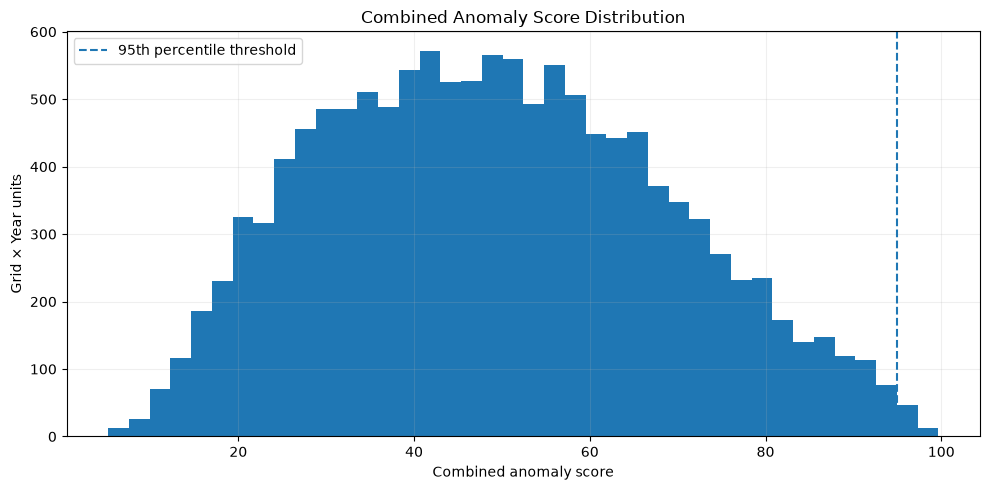

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    eligible["combined_anomaly_score"].dropna(),
    bins=40,
)

ax.axvline(
    ANOMALY_PERCENTILE_THRESHOLD,
    linestyle="--",
    label="95th percentile threshold",
)

ax.set_title("Combined Anomaly Score Distribution")
ax.set_xlabel("Combined anomaly score")
ax.set_ylabel("Grid × Year units")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


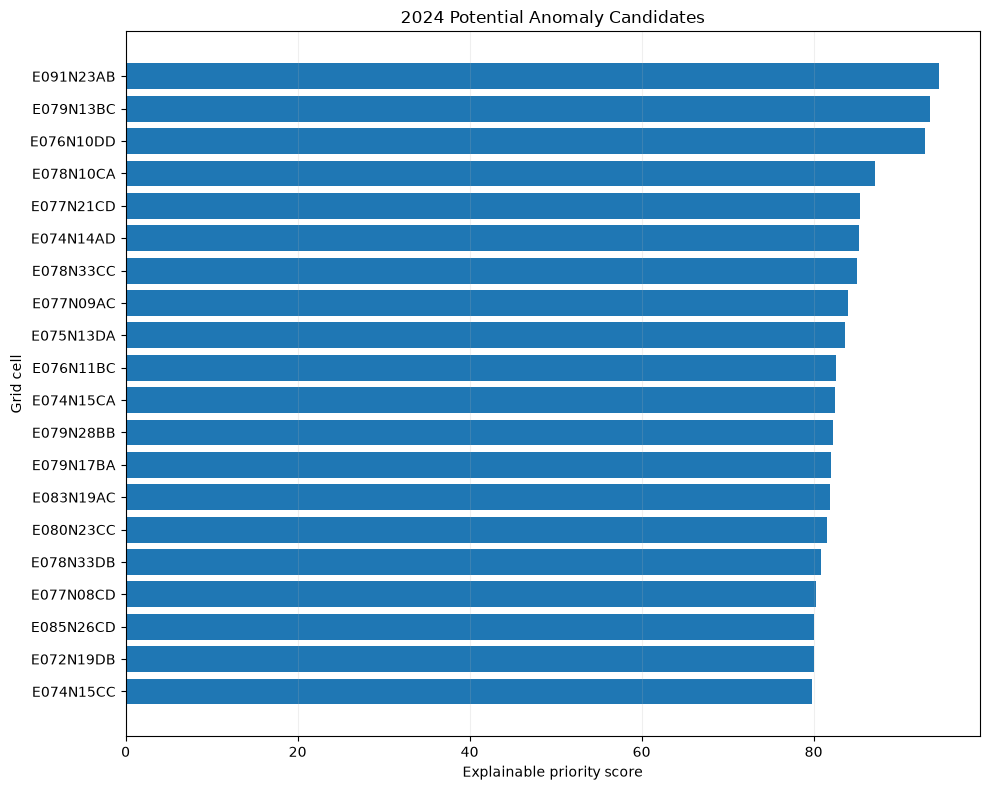

In [17]:
plot_2024 = anomalies_2024.head(20).sort_values(
    "priority_score"
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    plot_2024["eqdcellcode"].astype(str),
    plot_2024["priority_score"],
)

ax.set_title("2024 Potential Anomaly Candidates")
ax.set_xlabel("Explainable priority score")
ax.set_ylabel("Grid cell")
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()


## 15. Approximate spatial visualization

The GBIF cube stores the EQDGC cell code rather than the original coordinates in this processed dataset.

The decoder below computes an approximate cell centre for visualization. It is **not** used to reconstruct occurrence coordinates or calculate new geographic uncertainty.


In [18]:
import re

def decode_qdgc_center(code):
    m = re.fullmatch(
        r"([EW])(\d{3})([NS])(\d{2})([A-D]{2})",
        str(code),
    )

    if not m:
        return (np.nan, np.nan)

    ew, lon_deg, ns, lat_deg, suffix = m.groups()

    lon_deg = float(lon_deg)
    lat_deg = float(lat_deg)

    if ew == "E":
        lon_min, lon_max = lon_deg, lon_deg + 1
    else:
        lon_min, lon_max = -lon_deg - 1, -lon_deg

    if ns == "N":
        lat_min, lat_max = lat_deg, lat_deg + 1
    else:
        lat_min, lat_max = -lat_deg - 1, -lat_deg

    for letter in suffix:
        lon_mid = (lon_min + lon_max) / 2
        lat_mid = (lat_min + lat_max) / 2

        if letter == "A":       # NW
            lon_max, lat_min = lon_mid, lat_mid
        elif letter == "B":     # NE
            lon_min, lat_min = lon_mid, lat_mid
        elif letter == "C":     # SW
            lon_max, lat_max = lon_mid, lat_mid
        elif letter == "D":     # SE
            lon_min, lat_max = lon_mid, lat_mid

    return (
        (lon_min + lon_max) / 2,
        (lat_min + lat_max) / 2,
    )


spatial_2024 = anomalies_2024.copy()

centres = spatial_2024["eqdcellcode"].map(
    decode_qdgc_center
)

spatial_2024["longitude"] = centres.map(lambda x: x[0])
spatial_2024["latitude"] = centres.map(lambda x: x[1])

spatial_2024 = spatial_2024.dropna(
    subset=["longitude", "latitude"]
)

print(
    "2024 anomaly candidates with decodable grid centres:",
    len(spatial_2024)
)


2024 anomaly candidates with decodable grid centres: 246


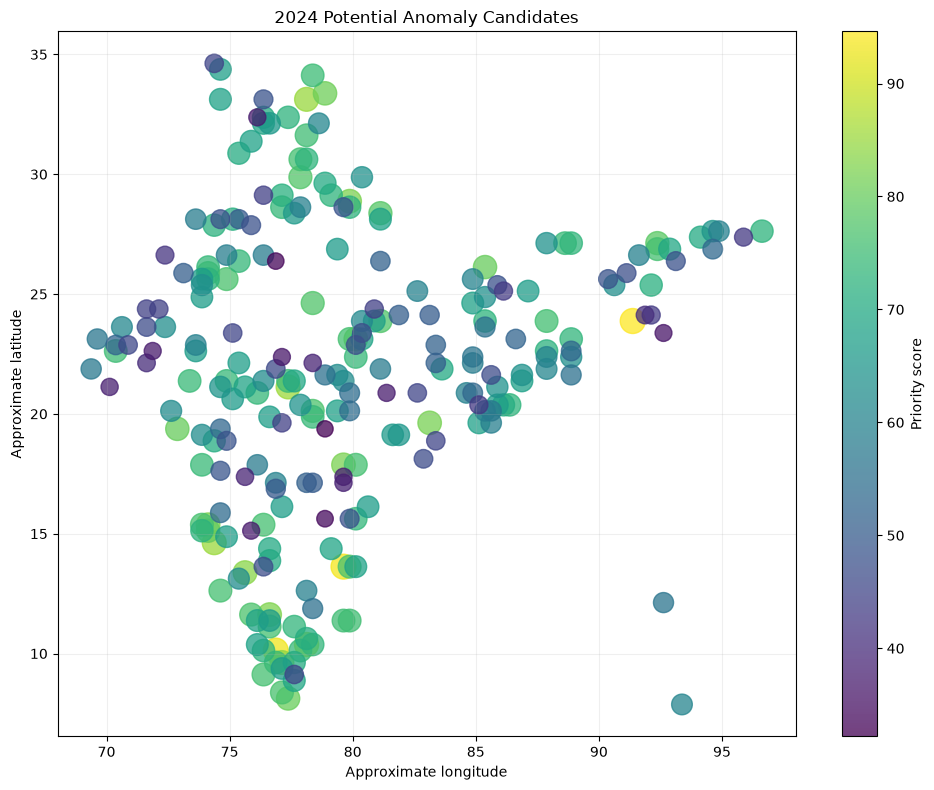

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))

if len(spatial_2024) > 0:
    scatter = ax.scatter(
        spatial_2024["longitude"],
        spatial_2024["latitude"],
        s=40 + 3 * spatial_2024["priority_score"],
        c=spatial_2024["priority_score"],
        alpha=0.75,
    )

    fig.colorbar(
        scatter,
        ax=ax,
        label="Priority score",
    )

ax.set_title("2024 Potential Anomaly Candidates")
ax.set_xlabel("Approximate longitude")
ax.set_ylabel("Approximate latitude")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 16. Export anomaly-intelligence outputs

In [20]:
ANOMALY_OUTPUT_PATH = (
    OUTPUT_DIR
    / "biosentinel_anomaly_intelligence.parquet"
)

ANOMALY_2024_PATH = (
    OUTPUT_DIR
    / "biosentinel_2024_anomaly_candidates.csv"
)

SENSITIVITY_PATH = (
    OUTPUT_DIR
    / "biosentinel_anomaly_sensitivity.csv"
)

SUMMARY_PATH = (
    OUTPUT_DIR
    / "biosentinel_anomaly_model_summary.json"
)

all_results.to_parquet(
    ANOMALY_OUTPUT_PATH,
    index=False,
)

anomalies_2024.to_csv(
    ANOMALY_2024_PATH,
    index=False,
)

sensitivity_df.to_csv(
    SENSITIVITY_PATH,
    index=False,
)

model_summary = {
    "analysis_start_year": ANALYSIS_START_YEAR,
    "analysis_end_year": ANALYSIS_END_YEAR,
    "model_train_end_year": MODEL_TRAIN_END_YEAR,
    "eligible_grid_year_units": int(len(eligible)),
    "eligible_grid_cells": int(
        eligible["eqdcellcode"].nunique()
    ),
    "preliminary_anomaly_candidates": int(
        eligible["preliminary_anomaly_flag"].sum()
    ),
    "potential_2024_candidates": int(
        len(anomalies_2024)
    ),
    "robust_deviation_threshold": ROBUST_DEVIATION_THRESHOLD,
    "anomaly_percentile_threshold": ANOMALY_PERCENTILE_THRESHOLD,
    "isolation_forest_contamination": IF_CONTAMINATION,
    "isolation_forest_random_state": IF_RANDOM_STATE,
    "spatial_effort_spearman_correlation": float(
        eligible[
            [
                "combined_anomaly_score",
                "log_observation_effort",
            ]
        ].corr(method="spearman").iloc[0, 1]
    ),
}

SUMMARY_PATH.write_text(
    json.dumps(model_summary, indent=2),
    encoding="utf-8",
)

print("Created:")
print("-", ANOMALY_OUTPUT_PATH)
print("-", ANOMALY_2024_PATH)
print("-", SENSITIVITY_PATH)
print("-", SUMMARY_PATH)


Created:
- d:\Biosential_India\data\processed\analytics\person3\biosentinel_anomaly_intelligence.parquet
- d:\Biosential_India\data\processed\analytics\person3\biosentinel_2024_anomaly_candidates.csv
- d:\Biosential_India\data\processed\analytics\person3\biosentinel_anomaly_sensitivity.csv
- d:\Biosential_India\data\processed\analytics\person3\biosentinel_anomaly_model_summary.json


# Part B — EfficientNet Species Identification

The image model is deliberately isolated from the GBIF anomaly pipeline.

### Expected local directory structure

```text
data/
└── raw/
    └── inaturalist/
        └── images/
            ├── Species_A/
            │   ├── image001.jpg
            │   └── ...
            ├── Species_B/
            │   └── ...
            └── ...
```

Classes with fewer than `MIN_IMAGES_PER_CLASS` images are excluded from the first training experiment.

**No synthetic fallback dataset is used.** If the image dataset is not present, the notebook stops this image branch with a clear message.


## 17. EfficientNet-B0 Experiment 2 — 50 images/species

Experiment 1 is preserved as the baseline. This experiment increases the supervised image dataset from 30 to **50 images per species** while keeping the **same five test images per species** from Experiment 1.

Experiment 2 uses:
- 1,106 species
- 50 images/species
- 35 train / 10 validation / 5 fixed test images per species
- GBIF-occurrence-level split protection
- stronger regularization and augmentation
- 2 warm-up + up to 8 fine-tuning epochs
- best-checkpoint selection by validation macro F1

The anomaly-detection branch above is unchanged. Only the species-identification experiment is upgraded here.


In [21]:
# Experiment 2 configuration

import torch
IMAGE_SIZE = 224
BATCH_SIZE = 32

# Windows/Jupyter-safe setting. The previous experiment was validated with
# NUM_WORKERS=0 after multiprocessing caused a stall.
NUM_WORKERS = 0
PREFETCH_FACTOR = 2

TARGET_SPECIES = 1106
TARGET_IMAGES_PER_SPECIES = 50
TARGET_TRAIN_PER_SPECIES = 35
TARGET_VAL_PER_SPECIES = 10
TARGET_TEST_PER_SPECIES = 5

EXPECTED_IMAGES = TARGET_SPECIES * TARGET_IMAGES_PER_SPECIES
EXPECTED_TRAIN_IMAGES = TARGET_SPECIES * TARGET_TRAIN_PER_SPECIES
EXPECTED_VAL_IMAGES = TARGET_SPECIES * TARGET_VAL_PER_SPECIES
EXPECTED_TEST_IMAGES = TARGET_SPECIES * TARGET_TEST_PER_SPECIES

# Reuse-aware manifest generation. Set True only if you intentionally want
# to regenerate the deterministic 50-image manifest.
REBUILD_EXP2_MANIFEST = False

# Download only rows that are missing locally.
DOWNLOAD_MISSING_IMAGES = True
MAX_DOWNLOAD_WORKERS = 12
DOWNLOAD_TIMEOUT = 45
DOWNLOAD_RETRIES = 4

# Training configuration
WARMUP_EPOCHS = 2
FINETUNE_EPOCHS = 8
EARLY_STOPPING_PATIENCE = 3

LEARNING_RATE_HEAD = 3e-4
LEARNING_RATE_FINETUNE = 5e-5
WEIGHT_DECAY = 5e-4
LABEL_SMOOTHING = 0.10
DROPOUT_P = 0.35
GRAD_CLIP_NORM = 1.0
TORCH_SEED = 42
SELECTION_SEED = 42
USE_AMP = True

torch.backends.cudnn.benchmark = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

print("Experiment 2 configuration ready.")
print("Target species:", TARGET_SPECIES)
print("Images/species:", TARGET_IMAGES_PER_SPECIES)
print("Train/Val/Test per species:", TARGET_TRAIN_PER_SPECIES, TARGET_VAL_PER_SPECIES, TARGET_TEST_PER_SPECIES)
print("Expected total images:", f"{EXPECTED_IMAGES:,}")
print("Batch size:", BATCH_SIZE)
print("Workers:", NUM_WORKERS)
print("AMP:", USE_AMP)
print("Rebuild manifest:", REBUILD_EXP2_MANIFEST)
print("Download missing images:", DOWNLOAD_MISSING_IMAGES)


Experiment 2 configuration ready.
Target species: 1106
Images/species: 50
Train/Val/Test per species: 35 10 5
Expected total images: 55,300
Batch size: 32
Workers: 0
AMP: True
Rebuild manifest: False
Download missing images: True


## 18. Build the Experiment 2 manifest

The manifest is constructed from the larger `efficientnet_manifest.csv` source. The five test images for every species are copied **exactly** from the completed Experiment 1 manifest so that the two experiments are directly comparable on the same held-out test images.

The original 21 train + 4 validation images are also retained. Additional deterministic candidates are then added to reach 35 train + 10 validation images per species.


In [22]:
from pathlib import Path
import hashlib
import pandas as pd


SELECTION_SEED = globals().get(
    "SELECTION_SEED",
    42,
)


def normalize_ids(frame):
    frame = frame.copy()

    for col in ["gbifID", "speciesKey", "split"]:
        if col in frame.columns:
            frame[col] = (
                frame[col]
                .astype("string")
                .str.strip()
            )

    frame["image_url"] = (
        frame["image_url"]
        .astype("string")
        .fillna("")
        .str.strip()
    )

    return frame


required = {
    "gbifID",
    "species",
    "speciesKey",
    "species_folder",
    "split",
    "image_url",
}


# ============================================================================
# LOAD MANIFESTS
# ============================================================================

if not IMAGE_MASTER_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Master manifest not found:\n"
        f"{IMAGE_MASTER_MANIFEST_PATH}"
    )

if not IMAGE_BASELINE_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Experiment 1 baseline manifest not found:\n"
        f"{IMAGE_BASELINE_MANIFEST_PATH}"
    )


master_manifest = normalize_ids(
    pd.read_csv(
        IMAGE_MASTER_MANIFEST_PATH,
        low_memory=False,
    )
)

baseline_manifest = normalize_ids(
    pd.read_csv(
        IMAGE_BASELINE_MANIFEST_PATH,
        low_memory=False,
    )
)


missing_master = required - set(
    master_manifest.columns
)

missing_baseline = required - set(
    baseline_manifest.columns
)

if missing_master:
    raise ValueError(
        f"Master manifest missing columns: "
        f"{sorted(missing_master)}"
    )

if missing_baseline:
    raise ValueError(
        f"Baseline manifest missing columns: "
        f"{sorted(missing_baseline)}"
    )


# ============================================================================
# VALIDATE EXPERIMENT 1
# ============================================================================

baseline_counts = (
    baseline_manifest
    .groupby("speciesKey")
    .size()
)

if (
    baseline_manifest["speciesKey"].nunique()
    != TARGET_SPECIES
    or baseline_counts.min() != 30
    or baseline_counts.max() != 30
):
    raise RuntimeError(
        "Experiment 1 baseline is not exactly "
        "1,106 species x 30 images/species."
    )


baseline_occurrence_split_counts = (
    baseline_manifest
    .groupby("gbifID")["split"]
    .nunique()
)

if baseline_occurrence_split_counts.max() > 1:
    raise RuntimeError(
        "Experiment 1 baseline contains "
        "occurrence leakage across splits."
    )


# ============================================================================
# BUILD EXPERIMENT 2
# ============================================================================

if (
    REBUILD_EXP2_MANIFEST
    or not IMAGE_MANIFEST_PATH.exists()
):

    parts = []

    baseline_species = (
        baseline_manifest[
            ["speciesKey", "species"]
        ]
        .drop_duplicates()
        .sort_values(
            ["speciesKey", "species"]
        )
    )

    for _, species_row in baseline_species.iterrows():

        species_key = str(
            species_row["speciesKey"]
        )

        # -----------------------------------------------------------------
        # Fixed Experiment 1 data
        # -----------------------------------------------------------------

        species_base = baseline_manifest[
            baseline_manifest["speciesKey"]
            == species_key
        ].copy()

        fixed_train = species_base[
            species_base["split"] == "train"
        ].copy()

        fixed_val = species_base[
            species_base["split"] == "val"
        ].copy()

        fixed_test = species_base[
            species_base["split"] == "test"
        ].copy()

        # Dynamic capacity requirements: handles standard species (21/4/5)
        # as well as occurrences with multi-photo groupings (e.g. 6DYRB with 21/6/3)
        extra_train_needed = (
            TARGET_TRAIN_PER_SPECIES - len(fixed_train)
        )

        extra_val_needed = (
            TARGET_IMAGES_PER_SPECIES
            - len(fixed_test)
            - len(fixed_train)
            - extra_train_needed
            - len(fixed_val)
        )

        if extra_val_needed < 0:
            extra_val_needed = 0
            extra_train_needed = (
                TARGET_IMAGES_PER_SPECIES
                - len(fixed_test)
                - len(fixed_train)
                - len(fixed_val)
            )

        base_test_occurrences = set(
            fixed_test["gbifID"].astype(str)
        )
        base_val_occurrences = set(
            fixed_val["gbifID"].astype(str)
        )
        base_train_occurrences = set(
            fixed_train["gbifID"].astype(str)
        )
        species_baseline_urls = set(
            species_base["image_url"].astype(str)
        )

        # -----------------------------------------------------------------
        # Master candidate filtering
        #
        # STRICT LEAKAGE RULES:
        # 1. Test occurrences are held out and strictly excluded from candidates.
        # 2. Baseline URLs already included are excluded.
        # 3. Candidates from occurrences already in baseline train can only be
        #    used in extra_train (safe reuse within the same split).
        # 4. Candidates from occurrences already in baseline val can only be
        #    used in extra_val.
        # 5. New occurrences not in baseline can be selected into extra_val
        #    or extra_train, but never both.
        # -----------------------------------------------------------------

        candidate = master_manifest[
            master_manifest["speciesKey"]
            == species_key
        ].copy()

        candidate = candidate[
            ~candidate["gbifID"]
            .astype(str)
            .isin(base_test_occurrences)
            & ~candidate["image_url"]
            .astype(str)
            .isin(species_baseline_urls)
            & candidate["gbifID"].notna()
            & candidate["image_url"].ne("")
        ].copy()

        # Remove exact duplicate media rows
        candidate = (
            candidate
            .drop_duplicates(
                subset=["gbifID", "image_url"],
                keep="first",
            )
            .reset_index(drop=True)
        )

        # Deterministic image ordering
        candidate["_image_hash"] = candidate.apply(
            lambda row: hashlib.sha256(
                (
                    f"{species_key}:"
                    f"{row['gbifID']}:"
                    f"{row['image_url']}:"
                    f"{SELECTION_SEED}"
                ).encode("utf-8")
            ).hexdigest(),
            axis=1,
        )

        # Separate candidates into new occurrences vs baseline split reuse
        is_new = ~candidate["gbifID"].astype(str).isin(
            base_train_occurrences | base_val_occurrences
        )
        is_train_reuse = candidate["gbifID"].astype(str).isin(
            base_train_occurrences
        )

        new_candidates = candidate[is_new].copy()
        train_reuse_pool = candidate[is_train_reuse].copy()

        # Group new occurrences
        occurrence_groups = []

        for gbif_id, group in new_candidates.groupby(
            "gbifID",
            sort=False,
        ):

            group = (
                group
                .sort_values(
                    "_image_hash",
                    kind="stable",
                )
                .copy()
            )

            occurrence_hash = hashlib.sha256(
                (
                    f"{species_key}:"
                    f"{gbif_id}:"
                    f"occurrence:{SELECTION_SEED}"
                ).encode("utf-8")
            ).hexdigest()

            occurrence_groups.append(
                {
                    "gbifID": str(gbif_id),
                    "capacity": len(group),
                    "hash": occurrence_hash,
                    "rows": group,
                }
            )

        occurrence_groups.sort(
            key=lambda item: item["hash"]
        )

        new_occ_capacity = sum(
            item["capacity"]
            for item in occurrence_groups
        )

        total_train_capacity = (
            new_occ_capacity + len(train_reuse_pool)
        )

        required_extra = (
            extra_train_needed + extra_val_needed
        )

        if total_train_capacity < required_extra:
            raise RuntimeError(
                f"Not enough candidate images for "
                f"{species_key}: "
                f"need {required_extra}, "
                f"found {total_train_capacity}."
            )

        # -----------------------------------------------------------------
        # Find a set of COMPLETE OCCURRENCES for validation.
        #
        # A small subset-sum search makes this robust when an occurrence
        # contains multiple photographs.
        # -----------------------------------------------------------------

        max_val_capacity = (
            total_train_capacity - extra_train_needed
        )

        if max_val_capacity < extra_val_needed:
            raise RuntimeError(
                f"Not enough capacity to split "
                f"{species_key} into "
                f"{extra_train_needed} train + "
                f"{extra_val_needed} val "
                f"without occurrence leakage."
            )

        reachable = [
            False
        ] * (
            max_val_capacity + 1
        )

        reachable[0] = True
        parent = {}

        for occurrence_index, item in enumerate(
            occurrence_groups
        ):

            capacity = item["capacity"]

            if capacity > max_val_capacity:
                continue

            for current_sum in range(
                max_val_capacity,
                capacity - 1,
                -1,
            ):

                previous_sum = (
                    current_sum - capacity
                )

                if (
                    reachable[previous_sum]
                    and not reachable[current_sum]
                ):
                    reachable[current_sum] = True
                    parent[current_sum] = (
                        previous_sum,
                        occurrence_index,
                    )

        # Choose the smallest achievable validation capacity >= extra_val_needed
        validation_capacity = None

        for value in range(
            extra_val_needed,
            max_val_capacity + 1,
        ):

            if reachable[value]:
                validation_capacity = value
                break

        if validation_capacity is None:
            capacities = [
                item["capacity"]
                for item in occurrence_groups
            ]
            raise RuntimeError(
                f"Could not create a leakage-safe split for {species_key}. "
                f"Candidate occurrence capacities: {capacities}"
            )

        # Reconstruct validation occurrence set
        selected_val_indices = set()
        current_sum = validation_capacity

        while current_sum > 0:
            previous_sum, occurrence_index = (
                parent[current_sum]
            )
            selected_val_indices.add(
                occurrence_index
            )
            current_sum = previous_sum

        # -----------------------------------------------------------------
        # Build validation images
        # -----------------------------------------------------------------

        val_parts = [
            occurrence_groups[idx]["rows"]
            for idx in selected_val_indices
        ]

        if len(val_parts) > 0:
            val_pool = (
                pd.concat(val_parts, ignore_index=True)
                .sort_values(
                    "_image_hash",
                    kind="stable",
                )
            )
        else:
            val_pool = pd.DataFrame(
                columns=candidate.columns
            )

        extra_val = val_pool.head(
            extra_val_needed
        ).copy()

        extra_val["split"] = "val"

        # -----------------------------------------------------------------
        # Build training images from remaining occurrences + safe train reuse
        # -----------------------------------------------------------------

        train_parts = [
            item["rows"]
            for idx, item in enumerate(occurrence_groups)
            if idx not in selected_val_indices
        ]

        if len(train_reuse_pool) > 0:
            train_parts.append(train_reuse_pool)

        if not train_parts:
            raise RuntimeError(
                f"No training occurrences remain for {species_key}."
            )

        train_pool = (
            pd.concat(train_parts, ignore_index=True)
            .sort_values(
                "_image_hash",
                kind="stable",
            )
        )

        if len(train_pool) < extra_train_needed:
            raise RuntimeError(
                f"Not enough training images remaining for {species_key}: "
                f"need {extra_train_needed}, found {len(train_pool)}"
            )

        extra_train = train_pool.head(
            extra_train_needed
        ).copy()

        extra_train["split"] = "train"

        # -----------------------------------------------------------------
        # Combine fixed Experiment 1 + Experiment 2 additions
        # -----------------------------------------------------------------

        parts.append(
            pd.concat(
                [
                    fixed_train,
                    extra_train,
                    fixed_val,
                    extra_val,
                    fixed_test,
                ],
                ignore_index=True,
            )
        )

    # =========================================================================
    # COMBINE ALL SPECIES
    # =========================================================================

    exp2_manifest = pd.concat(
        parts,
        ignore_index=True,
    )

    exp2_manifest = (
        exp2_manifest
        .drop_duplicates(
            subset=[
                "gbifID",
                "image_url",
            ],
            keep="first",
        )
        .drop(
            columns=[
                "_image_hash",
            ],
            errors="ignore",
        )
        .sort_values(
            [
                "speciesKey",
                "split",
                "gbifID",
                "image_url",
            ],
            kind="stable",
        )
        .reset_index(drop=True)
    )

    # =========================================================================
    # FINAL VALIDATION
    # =========================================================================

    per_species = (
        exp2_manifest
        .groupby("speciesKey")
        .size()
    )

    split_counts = (
        exp2_manifest
        .groupby(
            [
                "speciesKey",
                "split",
            ]
        )
        .size()
        .unstack(
            fill_value=0
        )
    )

    if len(exp2_manifest) != EXPECTED_IMAGES:
        raise RuntimeError(
            f"Expected {EXPECTED_IMAGES:,} rows, "
            f"found {len(exp2_manifest):,}."
        )

    if (
        exp2_manifest["speciesKey"].nunique()
        != TARGET_SPECIES
    ):
        raise RuntimeError(
            "Experiment 2 does not contain "
            "exactly 1,106 species."
        )

    if (
        per_species.min() != 50
        or per_species.max() != 50
    ):
        raise RuntimeError(
            "Experiment 2 must contain exactly "
            "50 images/species."
        )

    if not (
        split_counts["train"].ge(35).all()
        and split_counts["val"].ge(10).all()
        and (split_counts.sum(axis=1) == 50).all()
    ):
        raise RuntimeError(
            "Experiment 2 split counts must total exactly 50 images per species "
            "with at least 35 train and 10 validation images."
        )

    # -------------------------------------------------------------------------
    # Occurrence leakage check
    # -------------------------------------------------------------------------

    occurrence_split_counts = (
        exp2_manifest
        .groupby("gbifID")["split"]
        .nunique()
    )

    leakage = occurrence_split_counts[
        occurrence_split_counts > 1
    ]

    if len(leakage):
        raise RuntimeError(
            f"Experiment 2 occurrence leakage detected: "
            f"{len(leakage):,} occurrences."
        )

    # -------------------------------------------------------------------------
    # Confirm Experiment 1 test set is unchanged
    # -------------------------------------------------------------------------

    baseline_test_urls = set(
        baseline_manifest.loc[
            baseline_manifest["split"] == "test",
            "image_url",
        ].astype(str)
    )

    exp2_test_urls = set(
        exp2_manifest.loc[
            exp2_manifest["split"] == "test",
            "image_url",
        ].astype(str)
    )

    if baseline_test_urls != exp2_test_urls:
        raise RuntimeError(
            "Experiment 2 test set changed. "
            "The Experiment 1 test set must remain fixed."
        )

    # =========================================================================
    # WRITE
    # =========================================================================

    exp2_manifest.to_csv(
        IMAGE_MANIFEST_PATH,
        index=False,
    )

    print(
        "Created Experiment 2 manifest:",
        IMAGE_MANIFEST_PATH,
    )

else:

    exp2_manifest = normalize_ids(
        pd.read_csv(
            IMAGE_MANIFEST_PATH,
            low_memory=False,
        )
    )

    print(
        "Using existing Experiment 2 manifest:",
        IMAGE_MANIFEST_PATH,
    )

# ============================================================================
# FINAL AUDIT
# ============================================================================

print(
    "\nEXPERIMENT 2 MANIFEST AUDIT"
)

print(
    "---------------------------"
)

print(
    "Rows:",
    f"{len(exp2_manifest):,}"
)

print(
    "Species:",
    f"{exp2_manifest['speciesKey'].nunique():,}"
)

print(
    "Occurrences:",
    f"{exp2_manifest['gbifID'].nunique():,}"
)

print(
    "Images/species:",
    exp2_manifest
    .groupby("speciesKey")
    .size()
    .agg(
        ["min", "median", "max"]
    )
    .to_dict()
)

print("Split counts:")

print(
    exp2_manifest["split"]
    .value_counts()
    .reindex(
        ["train", "val", "test"]
    )
    .to_string()
)


Using existing Experiment 2 manifest: d:\Biosential_India\data\processed\inaturalist\efficientnet_50_exp2_manifest.csv

EXPERIMENT 2 MANIFEST AUDIT
---------------------------
Rows: 55,300
Species: 1,106
Occurrences: 42,515
Images/species: {'min': 50.0, 'median': 50.0, 'max': 50.0}
Split counts:
split
train    38710
val      11062
test      5528


## 19. Resolve local paths and verify the 55,300-image target

The downloader and training loader use the same deterministic filename rule. Existing Experiment 1 images are reused automatically; only newly selected Experiment 2 images are downloaded.


In [23]:
import hashlib
from PIL import Image

def local_image_filename(row):
    gbif_id = str(row["gbifID"]).strip()
    url = str(row["image_url"]).strip()
    url_hash = hashlib.sha1(url.encode("utf-8")).hexdigest()[:12]

    media_format = str(row.get("media_format", "")).strip().lower()
    if media_format in {"image/jpeg", "image/pjpeg"}:
        ext = ".jpg"
    elif media_format == "image/png":
        ext = ".png"
    elif media_format == "image/gif":
        ext = ".gif"
    elif media_format == "image/webp":
        ext = ".webp"
    else:
        ext = ".jpg"

    return f"{gbif_id}__{url_hash}{ext}"

exp2_manifest["local_path"] = exp2_manifest.apply(
    lambda row: str(
        IMAGE_ROOT
        / str(row["split"])
        / str(row["species_folder"])
        / local_image_filename(row)
    ),
    axis=1,
)

MODEL_MANIFEST_PATH = IMAGE_EXP2_OUTPUT_DIR / "efficientnet_exp2_input_manifest.csv"
exp2_manifest.to_csv(MODEL_MANIFEST_PATH, index=False)

missing_paths = [
    p for p in exp2_manifest["local_path"]
    if not Path(p).exists()
]

print("Experiment 2 manifest rows:", f"{len(exp2_manifest):,}")
print("Missing local images before download:", f"{len(missing_paths):,}")
print("Already present:", f"{len(exp2_manifest) - len(missing_paths):,}")
print("Input manifest copy:", MODEL_MANIFEST_PATH)


Experiment 2 manifest rows: 55,300
Missing local images before download: 0
Already present: 55,300
Input manifest copy: d:\Biosential_India\data\processed\analytics\person3\efficientnet_exp2_50img\efficientnet_exp2_input_manifest.csv


## 20. Download missing Experiment 2 images

This cell is resumable. It never redownloads a file that already exists. Downloads are validated with Pillow after writing, and partial files are removed on failure.


In [24]:
import mimetypes
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Lock
import requests

_download_print_lock = Lock()
SUPPORTED_FORMATS = {
    "image/jpeg": ".jpg",
    "image/pjpeg": ".jpg",
    "image/png": ".png",
    "image/gif": ".gif",
    "image/webp": ".webp",
}

def log_download(message):
    with _download_print_lock:
        print(message, flush=True)

def verify_image(path):
    try:
        with Image.open(path) as image:
            image.verify()
        return True
    except Exception:
        return False

def download_one_exp2(row):
    path = Path(row["local_path"])
    url = str(row["image_url"]).strip()

    if path.exists():
        if verify_image(path):
            return "existing", str(path)
        try:
            path.unlink()
        except Exception:
            pass

    if not url:
        return "failed:empty_url", str(path)

    path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = path.with_suffix(path.suffix + ".part")

    headers = {
        "User-Agent": "BioSentinel-India/1.0 (research biodiversity monitoring project)"
    }

    for attempt in range(1, DOWNLOAD_RETRIES + 1):
        try:
            response = requests.get(
                url,
                headers=headers,
                timeout=DOWNLOAD_TIMEOUT,
                stream=True,
            )
            response.raise_for_status()

            with temp_path.open("wb") as f:
                for chunk in response.iter_content(chunk_size=256 * 1024):
                    if chunk:
                        f.write(chunk)

            if not verify_image(temp_path):
                try:
                    temp_path.unlink()
                except Exception:
                    pass
                raise ValueError("downloaded file failed Pillow verification")

            temp_path.replace(path)
            return "downloaded", str(path)

        except Exception as exc:
            try:
                if temp_path.exists():
                    temp_path.unlink()
            except Exception:
                pass

            if attempt == DOWNLOAD_RETRIES:
                return f"failed:{type(exc).__name__}:{exc}", str(path)

            time.sleep(min(2 ** attempt, 10))

    return "failed:unknown", str(path)

if DOWNLOAD_MISSING_IMAGES:
    rows_to_download = exp2_manifest[
        ~exp2_manifest["local_path"].map(lambda p: Path(p).exists())
    ].to_dict(orient="records")

    print("Rows requiring download:", f"{len(rows_to_download):,}")

    results = []
    with ThreadPoolExecutor(max_workers=MAX_DOWNLOAD_WORKERS) as executor:
        futures = [executor.submit(download_one_exp2, row) for row in rows_to_download]
        total = len(futures)
        for index, future in enumerate(as_completed(futures), start=1):
            status, path = future.result()
            results.append((status, path))
            if index == 1 or index % 100 == 0 or index == total:
                downloaded = sum(1 for s, _ in results if s == "downloaded")
                failed = sum(1 for s, _ in results if s.startswith("failed:"))
                print(
                    f"Download progress: {index:,}/{total:,} | "
                    f"downloaded={downloaded:,} | failed={failed:,}"
                )

    failures = [(s, p) for s, p in results if s.startswith("failed:")]
    print("Download failures:", f"{len(failures):,}")
    if failures:
        print("First failures:")
        for failure in failures[:10]:
            print(failure)
else:
    print("DOWNLOAD_MISSING_IMAGES=False — download step skipped.")

missing_paths = [
    p for p in exp2_manifest["local_path"]
    if not Path(p).exists()
]

print("\nImages missing after download step:", f"{len(missing_paths):,}")
if missing_paths:
    raise FileNotFoundError(
        f"{len(missing_paths):,} Experiment 2 images are still missing."
    )

# Spot-check a small sample of the actual files.
for sample_path in exp2_manifest["local_path"].sample(
    min(25, len(exp2_manifest)),
    random_state=42,
):
    if not verify_image(sample_path):
        raise RuntimeError(f"Image failed verification: {sample_path}")

print("Image filesystem validation: PASSED")


Rows requiring download: 0
Download failures: 0

Images missing after download step: 0
Image filesystem validation: PASSED


## 21. PyTorch / CUDA setup

The experiment uses EfficientNet-B0 with ImageNet-pretrained weights, mixed precision on CUDA, and a fixed class mapping derived from speciesKey.


In [25]:
import sys
import torch    
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

USE_AMP = USE_AMP and torch.cuda.is_available()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training device:", device)
print("AMP enabled:", USE_AMP)


Python: 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]
PyTorch: 2.14.0+cu130
Torchvision: 0.29.0+cu130
CUDA available: True
CUDA version: 13.0
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM GB: 6.0
Training device: cuda
AMP enabled: True


## 22. Dataset objects and stronger augmentation

The training transform increases geometric and photometric variation while preserving the taxonomic signal. Label smoothing and classifier dropout are also used as regularization.


In [26]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.60, 1.0),
        ratio=(0.85, 1.15),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.20,
        hue=0.05,
    ),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.10,
        scale=(0.02, 0.10),
        ratio=(0.3, 3.3),
        value=0,
    ),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD,
    ),
])

class SpeciesImageDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.frame = frame.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row["local_path"]) as image:
            image = image.convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row["label"])

# Stable species-to-index mapping.
class_table = (
    exp2_manifest[["speciesKey", "species"]]
    .drop_duplicates()
    .sort_values(["speciesKey", "species"])
    .reset_index(drop=True)
)

ordered_species_keys = class_table["speciesKey"].astype(str).tolist()
ordered_class_names = class_table["species"].astype(str).tolist()
num_classes = len(ordered_class_names)
label_map = {key: i for i, key in enumerate(ordered_species_keys)}

exp2_manifest["label"] = (
    exp2_manifest["speciesKey"].astype(str).map(label_map).astype(int)
)

train_frame = exp2_manifest[exp2_manifest["split"] == "train"].copy()
val_frame = exp2_manifest[exp2_manifest["split"] == "val"].copy()
test_frame = exp2_manifest[exp2_manifest["split"] == "test"].copy()

train_dataset = SpeciesImageDataset(train_frame, train_transform)
val_dataset = SpeciesImageDataset(val_frame, eval_transform)
test_dataset = SpeciesImageDataset(test_frame, eval_transform)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
}

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

print("Classes:", num_classes)
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

if num_classes != TARGET_SPECIES:
    raise RuntimeError(f"Expected {TARGET_SPECIES} classes, found {num_classes}.")


Classes: 1106
Train images: 38710
Validation images: 11062
Test images: 5528
Train batches: 1210
Val batches: 346
Test batches: 173


## 23. DataLoader and GPU smoke test

This is intentionally small. It confirms the exact Experiment 2 loader, CUDA transfer, AMP, and EfficientNet forward path before spending hours on training.


In [27]:
import time

images, labels = next(iter(train_loader))
print("First batch shape:", images.shape)
print("Labels shape:", labels.shape)

images_gpu = images.to(device, non_blocking=True)
if device.type == "cuda":
    images_gpu = images_gpu.contiguous(memory_format=torch.channels_last)

model_smoke = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_smoke.classifier[1] = nn.Linear(
    model_smoke.classifier[1].in_features,
    num_classes,
)
model_smoke = model_smoke.to(device)
if device.type == "cuda":
    model_smoke = model_smoke.to(memory_format=torch.channels_last)
model_smoke.eval()

with torch.inference_mode():
    with torch.autocast(
        device_type=device.type,
        dtype=torch.float16,
        enabled=USE_AMP,
    ):
        # Warm-up
        for _ in range(2):
            _ = model_smoke(images_gpu)
        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()
        outputs_smoke = model_smoke(images_gpu)
        if device.type == "cuda":
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - start

print("Forward time after warm-up:", f"{elapsed:.4f}s")
print("Output shape:", outputs_smoke.shape)
print("GPU allocated MB:", round(torch.cuda.memory_allocated() / 1024**2, 1) if device.type == "cuda" else 0)

del model_smoke, outputs_smoke, images_gpu
if device.type == "cuda":
    torch.cuda.empty_cache()

print("GPU smoke test: PASSED")


First batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Forward time after warm-up: 0.0167s
Output shape: torch.Size([32, 1106])
GPU allocated MB: 48.4
GPU smoke test: PASSED


## 24. Build EfficientNet-B0 model

The backbone starts from ImageNet-pretrained EfficientNet-B0. The classifier is replaced with 1,106 species outputs and regularized with increased dropout.


In [28]:
torch.manual_seed(TORCH_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TORCH_SEED)

weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

model.classifier[0] = nn.Dropout(
    p=DROPOUT_P,
    inplace=True,
)
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes,
)

# Warm-up: train only the classifier first.
for parameter in model.features.parameters():
    parameter.requires_grad = False

model = model.to(device)
if device.type == "cuda":
    model = model.to(memory_format=torch.channels_last)

criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING,
)

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=LEARNING_RATE_HEAD,
    weight_decay=WEIGHT_DECAY,
)

amp_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)

print("EfficientNet-B0 ready.")
print("Classes:", num_classes)
print("Classifier dropout:", DROPOUT_P)
print("Label smoothing:", LABEL_SMOOTHING)


EfficientNet-B0 ready.
Classes: 1106
Classifier dropout: 0.35
Label smoothing: 0.1


## 25. Training utilities

The training loop records top-1, top-5, macro precision, macro recall, and macro F1, with visible batch progress. The best checkpoint is selected exclusively using validation macro F1.


In [29]:
def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    scaler=None,
    phase_name="eval",
):
    is_training = optimizer is not None
    model.train(is_training)

    running_loss = 0.0
    total = 0
    correct = 0
    top5_correct = 0
    all_targets = []
    all_predictions = []
    total_batches = len(loader)

    for batch_index, (images, labels) in enumerate(loader, start=1):
        if device.type == "cuda":
            images = images.to(device, non_blocking=True).to(memory_format=torch.channels_last)
            labels = labels.to(device, non_blocking=True)
        else:
            images = images.to(device)
            labels = labels.to(device)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if is_training:
                if scaler is not None and USE_AMP:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        GRAD_CLIP_NORM,
                    )
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        GRAD_CLIP_NORM,
                    )
                    optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total += batch_size

        predictions = outputs.argmax(dim=1)
        correct += int((predictions == labels).sum().item())

        k = min(5, outputs.shape[1])
        top5_predictions = outputs.topk(k=k, dim=1).indices
        top5_correct += int(
            (top5_predictions == labels.unsqueeze(1)).any(dim=1).sum().item()
        )

        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_predictions.extend(predictions.detach().cpu().numpy().tolist())

        if (
            batch_index == 1
            or batch_index % 50 == 0
            or batch_index == total_batches
        ):
            current_loss = running_loss / max(total, 1)
            current_acc = correct / max(total, 1)
            progress_pct = batch_index / total_batches * 100
            print(
                f"\r{phase_name}: {batch_index:,}/{total_batches:,} "
                f"({progress_pct:5.1f}%) | loss={current_loss:.4f} | acc={current_acc:.4f}",
                end="",
                flush=True,
            )

    print()

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0,
    )

    return {
        "loss": running_loss / max(total, 1),
        "accuracy": correct / max(total, 1),
        "top5_accuracy": top5_correct / max(total, 1),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "targets": np.asarray(all_targets),
        "predictions": np.asarray(all_predictions),
    }

def save_checkpoint(path, epoch, model, metrics, phase):
    torch.save(
        {
            "epoch": epoch,
            "phase": phase,
            "model_state_dict": model.state_dict(),
            "class_names": ordered_class_names,
            "species_keys": ordered_species_keys,
            "metrics": metrics,
            "experiment": "BioSentinel India EfficientNet-B0 Experiment 2 — 50 images/species",
        },
        path,
    )

history = []
best_val_f1 = -np.inf
best_epoch = None

BEST_CHECKPOINT_PATH = IMAGE_EXP2_MODEL_DIR / "efficientnet_b0_biosentinel_exp2_50img_best.pth"
FINAL_MODEL_PATH = IMAGE_EXP2_MODEL_DIR / "efficientnet_b0_biosentinel_exp2_50img_final.pth"
MODEL_METRICS_PATH = IMAGE_EXP2_OUTPUT_DIR / "efficientnet_b0_exp2_test_metrics.json"
HISTORY_PATH = IMAGE_EXP2_OUTPUT_DIR / "efficientnet_b0_exp2_training_history.csv"
CLASSIFICATION_REPORT_PATH = IMAGE_EXP2_OUTPUT_DIR / "efficientnet_b0_exp2_classification_report.txt"

print("Training utilities ready.")


Training utilities ready.


## 26. Warm-up training — 2 epochs

Only the classifier is trainable during warm-up.


In [30]:
warmup_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=WARMUP_EPOCHS,
    eta_min=LEARNING_RATE_HEAD * 0.1,
)

for epoch in range(1, WARMUP_EPOCHS + 1):
    print(f"\n=== WARM-UP EPOCH {epoch}/{WARMUP_EPOCHS} ===")

    train_metrics = run_epoch(
        model, train_loader, criterion, optimizer, amp_scaler,
        phase_name=f"warmup train {epoch}",
    )
    val_metrics = run_epoch(
        model, val_loader, criterion,
        phase_name=f"warmup val {epoch}",
    )

    history.append({
        "epoch": epoch,
        "phase": "warmup",
        **{f"train_{k}": v for k, v in train_metrics.items() if k not in {"targets", "predictions"}},
        **{f"val_{k}": v for k, v in val_metrics.items() if k not in {"targets", "predictions"}},
    })

    warmup_scheduler.step()

    print(
        f"Warm-up epoch {epoch}/{WARMUP_EPOCHS} | "
        f"train F1={train_metrics['macro_f1']:.4f} | "
        f"val F1={val_metrics['macro_f1']:.4f} | "
        f"val top-5={val_metrics['top5_accuracy']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        save_checkpoint(
            BEST_CHECKPOINT_PATH,
            epoch,
            model,
            val_metrics,
            "warmup",
        )

print("Best validation macro F1 after warm-up:", f"{best_val_f1:.4f}")



=== WARM-UP EPOCH 1/2 ===
warmup train 1: 1,210/1,210 (100.0%) | loss=6.3843 | acc=0.0712
warmup val 1: 346/346 (100.0%) | loss=5.6460 | acc=0.1723
Warm-up epoch 1/2 | train F1=0.0648 | val F1=0.1404 | val top-5=0.3640

=== WARM-UP EPOCH 2/2 ===
warmup train 2: 1,210/1,210 (100.0%) | loss=5.3634 | acc=0.2145
warmup val 2: 346/346 (100.0%) | loss=5.2735 | acc=0.2049
Warm-up epoch 2/2 | train F1=0.1869 | val F1=0.1691 | val top-5=0.4111
Best validation macro F1 after warm-up: 0.1691


## 27. Full fine-tuning — up to 8 epochs

The full EfficientNet backbone is unfrozen. Lower learning rate, stronger weight decay, label smoothing, dropout, augmentation, gradient clipping, and early stopping address the overfitting observed in Experiment 1.


In [31]:
for parameter in model.features.parameters():
    parameter.requires_grad = True

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE_FINETUNE,
    weight_decay=WEIGHT_DECAY,
)

amp_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)

fine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=FINETUNE_EPOCHS,
    eta_min=LEARNING_RATE_FINETUNE * 0.05,
)

no_improvement = 0
start_epoch = WARMUP_EPOCHS

for offset in range(1, FINETUNE_EPOCHS + 1):
    epoch = start_epoch + offset
    print(
        f"\n=== FINE-TUNE EPOCH {offset}/{FINETUNE_EPOCHS} (global {epoch}) ==="
    )

    train_metrics = run_epoch(
        model, train_loader, criterion, optimizer, amp_scaler,
        phase_name=f"finetune train {offset}",
    )
    val_metrics = run_epoch(
        model, val_loader, criterion,
        phase_name=f"finetune val {offset}",
    )

    history.append({
        "epoch": epoch,
        "phase": "finetune",
        **{f"train_{k}": v for k, v in train_metrics.items() if k not in {"targets", "predictions"}},
        **{f"val_{k}": v for k, v in val_metrics.items() if k not in {"targets", "predictions"}},
    })

    fine_scheduler.step()

    print(
        f"Fine-tune epoch {offset}/{FINETUNE_EPOCHS} | "
        f"train F1={train_metrics['macro_f1']:.4f} | "
        f"val F1={val_metrics['macro_f1']:.4f} | "
        f"val top-5={val_metrics['top5_accuracy']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        no_improvement = 0
        save_checkpoint(
            BEST_CHECKPOINT_PATH,
            epoch,
            model,
            val_metrics,
            "finetune",
        )
    else:
        no_improvement += 1
        print(
            f"No validation F1 improvement for {no_improvement} epoch(s)."
        )
        if no_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered.")
            break

print("Best validation macro F1:", f"{best_val_f1:.4f}")
print("Best epoch:", best_epoch)



=== FINE-TUNE EPOCH 1/8 (global 3) ===
finetune train 1: 1,210/1,210 (100.0%) | loss=4.1964 | acc=0.3257
finetune val 1: 346/346 (100.0%) | loss=3.8367 | acc=0.3511
Fine-tune epoch 1/8 | train F1=0.2945 | val F1=0.3139 | val top-5=0.6204

=== FINE-TUNE EPOCH 2/8 (global 4) ===
finetune train 2: 1,210/1,210 (100.0%) | loss=3.6108 | acc=0.4291
finetune val 2: 346/346 (100.0%) | loss=3.5543 | acc=0.4071
Fine-tune epoch 2/8 | train F1=0.4077 | val F1=0.3802 | val top-5=0.6728

=== FINE-TUNE EPOCH 3/8 (global 5) ===
finetune train 3: 1,210/1,210 (100.0%) | loss=3.3161 | acc=0.4894
finetune val 3: 346/346 (100.0%) | loss=3.3705 | acc=0.4492
Fine-tune epoch 3/8 | train F1=0.4755 | val F1=0.4265 | val top-5=0.7117

=== FINE-TUNE EPOCH 4/8 (global 6) ===
finetune train 4: 1,210/1,210 (100.0%) | loss=3.1222 | acc=0.5340
finetune val 4: 346/346 (100.0%) | loss=3.2679 | acc=0.4674
Fine-tune epoch 4/8 | train F1=0.5230 | val F1=0.4470 | val top-5=0.7266

=== FINE-TUNE EPOCH 5/8 (global 7) ===
fine

## 28. Plot Experiment 2 training history


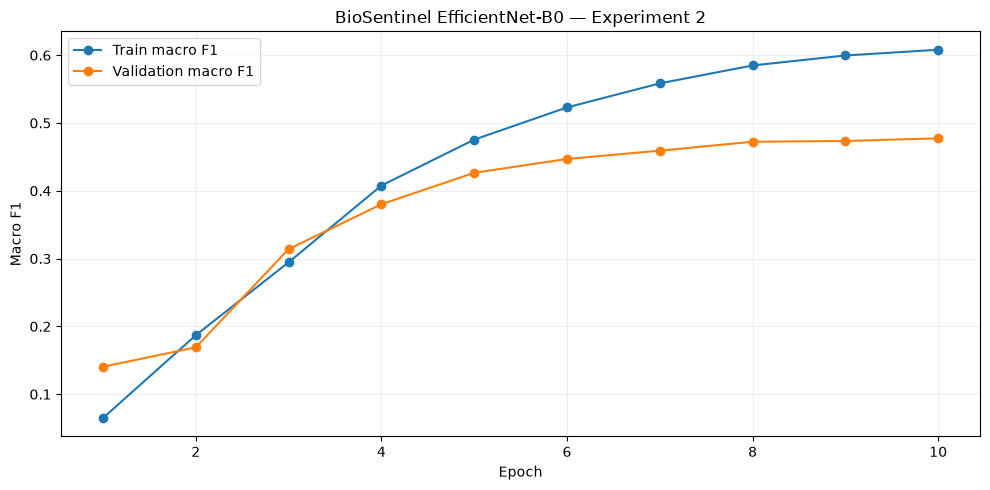

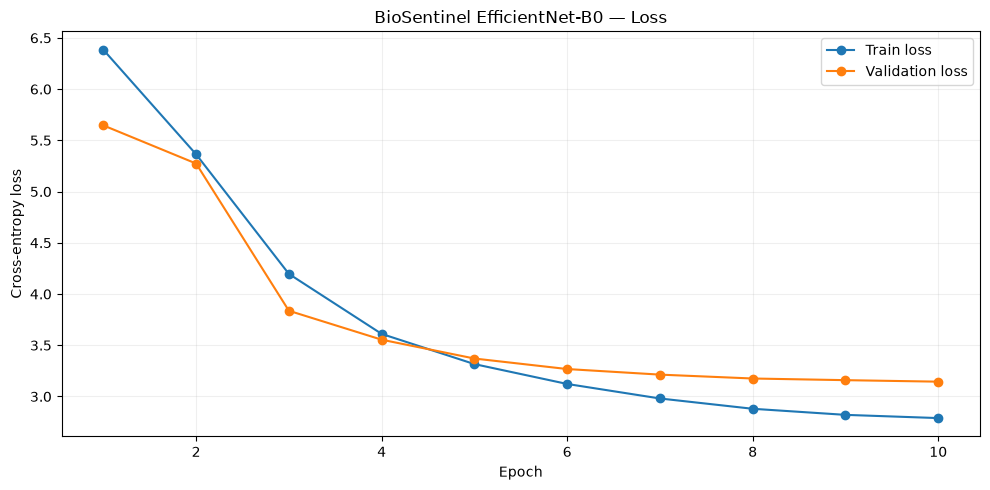

History saved: d:\Biosential_India\data\processed\analytics\person3\efficientnet_exp2_50img\efficientnet_b0_exp2_training_history.csv


In [32]:
history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_df["epoch"], history_df["train_macro_f1"], marker="o", label="Train macro F1")
ax.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="Validation macro F1")
ax.set_title("BioSentinel EfficientNet-B0 — Experiment 2")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro F1")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
ax.set_title("BioSentinel EfficientNet-B0 — Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
plt.close(fig)

HISTORY_PATH.parent.mkdir(parents=True, exist_ok=True)
history_df.to_csv(HISTORY_PATH, index=False)
print("History saved:", HISTORY_PATH)


## 29. Load the best checkpoint and evaluate the fixed test set


In [33]:
checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(checkpoint["model_state_dict"])
print("Loaded best checkpoint from epoch:", checkpoint["epoch"])
print("Validation macro F1 at checkpoint:", f"{checkpoint['metrics']['macro_f1']:.4f}")

test_metrics = run_epoch(
    model,
    test_loader,
    criterion,
    phase_name="test",
)

targets = test_metrics["targets"]
predictions = test_metrics["predictions"]

print("\n=== EXPERIMENT 2 TEST RESULTS ===")
print("Test accuracy:", f"{test_metrics['accuracy']:.4f}")
print("Test top-5 accuracy:", f"{test_metrics['top5_accuracy']:.4f}")
print("Test macro precision:", f"{test_metrics['macro_precision']:.4f}")
print("Test macro recall:", f"{test_metrics['macro_recall']:.4f}")
print("Test macro F1:", f"{test_metrics['macro_f1']:.4f}")

classification_text = classification_report(
    targets,
    predictions,
    target_names=ordered_class_names,
    zero_division=0,
)
CLASSIFICATION_REPORT_PATH.write_text(
    classification_text,
    encoding="utf-8",
)

print("Full classification report saved:", CLASSIFICATION_REPORT_PATH)
print("Classification report preview:")
print("\n".join(classification_text.splitlines()[:15]))


Loaded best checkpoint from epoch: 10
Validation macro F1 at checkpoint: 0.4775
test: 173/173 (100.0%) | loss=3.1119 | acc=0.5002

=== EXPERIMENT 2 TEST RESULTS ===
Test accuracy: 0.5002
Test top-5 accuracy: 0.7484
Test macro precision: 0.5130
Test macro recall: 0.5001
Test macro F1: 0.4794
Full classification report saved: d:\Biosential_India\data\processed\analytics\person3\efficientnet_exp2_50img\efficientnet_b0_exp2_classification_report.txt
Classification report preview:
                                precision    recall  f1-score   support

        Cucumis maderaspatanus       0.43      0.60      0.50         5
              Cupha erymanthis       0.50      0.60      0.55         5
          Curculigo orchioides       0.42      1.00      0.59         5
                Curetis thetis       1.00      0.60      0.75         5
            Cyanotis axillaris       0.38      0.60      0.46         5
             Cyanotis cristata       0.80      0.80      0.80         5
          Cyan

## 30. Confusion matrix — fixed-size rendering

The full 1,106 × 1,106 matrix is retained; only a manageable subset of axis labels is displayed so Matplotlib does not allocate an enormous canvas.


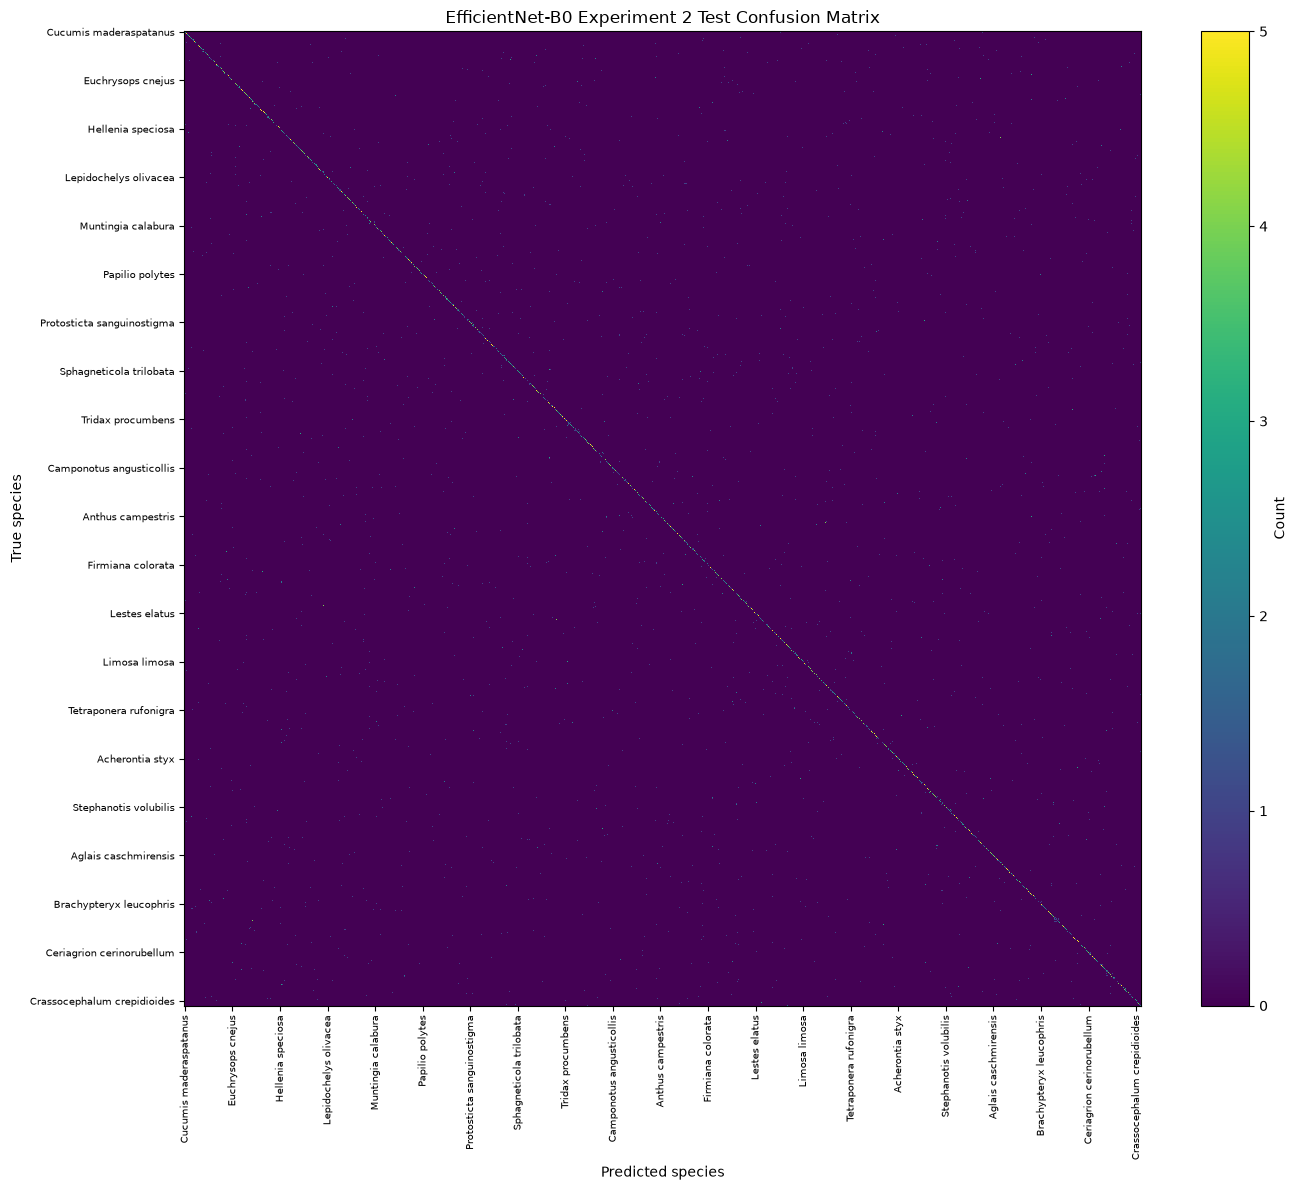

In [34]:
cm = confusion_matrix(
    targets,
    predictions,
    labels=np.arange(num_classes),
)

fig, ax = plt.subplots(figsize=(14, 12), dpi=100)
image = ax.imshow(
    cm,
    aspect="auto",
    interpolation="nearest",
)
ax.set_title("EfficientNet-B0 Experiment 2 Test Confusion Matrix")
ax.set_xlabel("Predicted species")
ax.set_ylabel("True species")

tick_step = max(1, num_classes // 20)
tick_positions = np.arange(0, num_classes, tick_step)
ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)
ax.set_xticklabels(
    [ordered_class_names[i] for i in tick_positions],
    rotation=90,
    fontsize=7,
)
ax.set_yticklabels(
    [ordered_class_names[i] for i in tick_positions],
    fontsize=7,
)
fig.colorbar(image, ax=ax, label="Count")
plt.tight_layout()
plt.show()
plt.close(fig)


## 31. Compare Experiment 2 with the completed Experiment 1 baseline


In [35]:
baseline_metrics_path = OUTPUT_DIR / "efficientnet_b0_test_metrics.json"
comparison_path = IMAGE_EXP2_OUTPUT_DIR / "efficientnet_exp1_vs_exp2_comparison.json"

comparison = {
    "experiment_1": {
        "test_accuracy": None,
        "test_macro_precision": None,
        "test_macro_recall": None,
        "test_macro_f1": None,
    },
    "experiment_2": {
        "test_accuracy": float(test_metrics["accuracy"]),
        "test_top5_accuracy": float(test_metrics["top5_accuracy"]),
        "test_macro_precision": float(test_metrics["macro_precision"]),
        "test_macro_recall": float(test_metrics["macro_recall"]),
        "test_macro_f1": float(test_metrics["macro_f1"]),
    },
}

if baseline_metrics_path.exists():
    exp1 = json.loads(baseline_metrics_path.read_text(encoding="utf-8"))
    for key in comparison["experiment_1"]:
        comparison["experiment_1"][key] = exp1.get(key)

    comparison["delta"] = {
        key: float(comparison["experiment_2"][key] - comparison["experiment_1"][key])
        for key in ["test_accuracy", "test_macro_precision", "test_macro_recall", "test_macro_f1"]
        if comparison["experiment_1"][key] is not None
    }
else:
    comparison["delta"] = {}
    print("Experiment 1 metrics JSON not found; comparison deltas unavailable.")

comparison_path.write_text(
    json.dumps(comparison, indent=2),
    encoding="utf-8",
)

print(json.dumps(comparison, indent=2))
print("Comparison saved:", comparison_path)


{
  "experiment_1": {
    "test_accuracy": 0.42601302460202606,
    "test_macro_precision": 0.4384006427067006,
    "test_macro_recall": 0.4258589511754069,
    "test_macro_f1": 0.4108155534917945
  },
  "experiment_2": {
    "test_accuracy": 0.5001808972503617,
    "test_top5_accuracy": 0.7483719247467439,
    "test_macro_precision": 0.5129961623157884,
    "test_macro_recall": 0.5001205545509343,
    "test_macro_f1": 0.47939467648429185
  },
  "delta": {
    "test_accuracy": 0.07416787264833569,
    "test_macro_precision": 0.07459551960908778,
    "test_macro_recall": 0.0742616033755274,
    "test_macro_f1": 0.06857912299249735
  }
}
Comparison saved: d:\Biosential_India\data\processed\analytics\person3\efficientnet_exp2_50img\efficientnet_exp1_vs_exp2_comparison.json


## 32. Export Experiment 2 model and metrics


In [36]:
image_metrics = {
    "experiment": "BioSentinel India EfficientNet-B0 Experiment 2 — 50 images/species",
    "device": str(device),
    "num_classes": int(num_classes),
    "classes": ordered_class_names,
    "images_per_species": int(TARGET_IMAGES_PER_SPECIES),
    "train_images": int(len(train_dataset)),
    "validation_images": int(len(val_dataset)),
    "test_images": int(len(test_dataset)),
    "train_per_species": int(TARGET_TRAIN_PER_SPECIES),
    "validation_per_species": int(TARGET_VAL_PER_SPECIES),
    "test_per_species": int(TARGET_TEST_PER_SPECIES),
    "warmup_epochs": int(WARMUP_EPOCHS),
    "finetune_epochs_max": int(FINETUNE_EPOCHS),
    "best_epoch": int(checkpoint["epoch"]),
    "learning_rate_head": float(LEARNING_RATE_HEAD),
    "learning_rate_finetune": float(LEARNING_RATE_FINETUNE),
    "weight_decay": float(WEIGHT_DECAY),
    "label_smoothing": float(LABEL_SMOOTHING),
    "dropout": float(DROPOUT_P),
    "test_accuracy": float(test_metrics["accuracy"]),
    "test_top5_accuracy": float(test_metrics["top5_accuracy"]),
    "test_macro_precision": float(test_metrics["macro_precision"]),
    "test_macro_recall": float(test_metrics["macro_recall"]),
    "test_macro_f1": float(test_metrics["macro_f1"]),
}

MODEL_METRICS_PATH.write_text(
    json.dumps(image_metrics, indent=2),
    encoding="utf-8",
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": ordered_class_names,
        "species_keys": ordered_species_keys,
        "image_size": IMAGE_SIZE,
        "experiment": "BioSentinel India EfficientNet-B0 Experiment 2 — 50 images/species",
        "test_metrics": image_metrics,
    },
    FINAL_MODEL_PATH,
)

print("Created:")
print("-", HISTORY_PATH)
print("-", MODEL_METRICS_PATH)
print("-", CLASSIFICATION_REPORT_PATH)
print("-", IMAGE_MANIFEST_PATH)
print("-", BEST_CHECKPOINT_PATH)
print("-", FINAL_MODEL_PATH)


Created:
- d:\Biosential_India\data\processed\analytics\person3\efficientnet_exp2_50img\efficientnet_b0_exp2_training_history.csv
- d:\Biosential_India\data\processed\analytics\person3\efficientnet_exp2_50img\efficientnet_b0_exp2_test_metrics.json
- d:\Biosential_India\data\processed\analytics\person3\efficientnet_exp2_50img\efficientnet_b0_exp2_classification_report.txt
- d:\Biosential_India\data\processed\inaturalist\efficientnet_50_exp2_manifest.csv
- d:\Biosential_India\models\efficientnet_exp2_50img\efficientnet_b0_biosentinel_exp2_50img_best.pth
- d:\Biosential_India\models\efficientnet_exp2_50img\efficientnet_b0_biosentinel_exp2_50img_final.pth


## 33. Experiment 2 completion summary

The notebook now leaves Experiment 1 untouched and records Experiment 2 in separate manifest, metrics, history, checkpoint, and final-model paths.

Run order after restart: execute the notebook from the beginning. The anomaly-analysis cells remain unchanged; the image branch builds/reuses the 50-image manifest, downloads only missing files, trains EfficientNet-B0, evaluates the fixed test set, and exports Experiment 2 artifacts.
